In [1]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.devices())
import jaxlib
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk
import os
import glob
import sys

sys.path.append("/home/ihuarte/Escritorio/Ivan/NNs")

# os.chdir("/home/ihuarte/Escritorio/Ivan/NN/")

from VA_project.model.model import J1J2Square
from VA_project.engine.runners import Runner

# from NN_utils import load_vstate
# from correlations import correlations_vstate

# from NNs.NN_module.ST_utils import compare_params, masked_optimizer
from frozendict import deepfreeze
from NN_module.ST_utils import print_tree

[CudaDevice(id=0)]


In [2]:
def distance_with_neel(size):
    N = jnp.prod(jnp.array(size))
    i, j = jnp.unravel_index(jnp.arange(N), size)
    neel_A = (-1)**(i+j).reshape(size)
    neel_B = -1.0 * neel_A
    def _compare(x):
        distance_A = jnp.sum(jnp.abs(x-neel_A))
        distance_B = jnp.sum(jnp.abs(x-neel_B))

        if distance_A < distance_B:
            return distance_A, "Neel-A"
        elif distance_B < distance_A:
            return distance_B, "Neel-B"
        else:
            return distance_A, "Same in Neel-A and Neel-B"
        
    return _compare

def distance_with_stripped(size):
    N = jnp.prod(jnp.array(size))
    stripped_VA = (-1)**jnp.arange(N).reshape(size)
    stripped_VB = -1.0 * stripped_VA
    stripped_HA = stripped_VA.T
    stripped_HB = -1.0 * stripped_HA
    patterns = [stripped_VA, stripped_VB, stripped_HA, stripped_HB]
    labels = [
        "VA", "VB",
        "HA", "HB"
    ]

    def _compare(x):
        distances = jnp.array([
            jnp.sum(jnp.abs(x - p)) for p in patterns
        ])

        dmin = jnp.min(distances)
        mask = distances == dmin

        equal_labels = [label for label, m in zip(labels, mask) if bool(m)]
        label_out = "Stripped-"

        for s in equal_labels:
            label_out += f"{s}-"
        label_out = label_out[:-1]

        return dmin, label_out

    return _compare


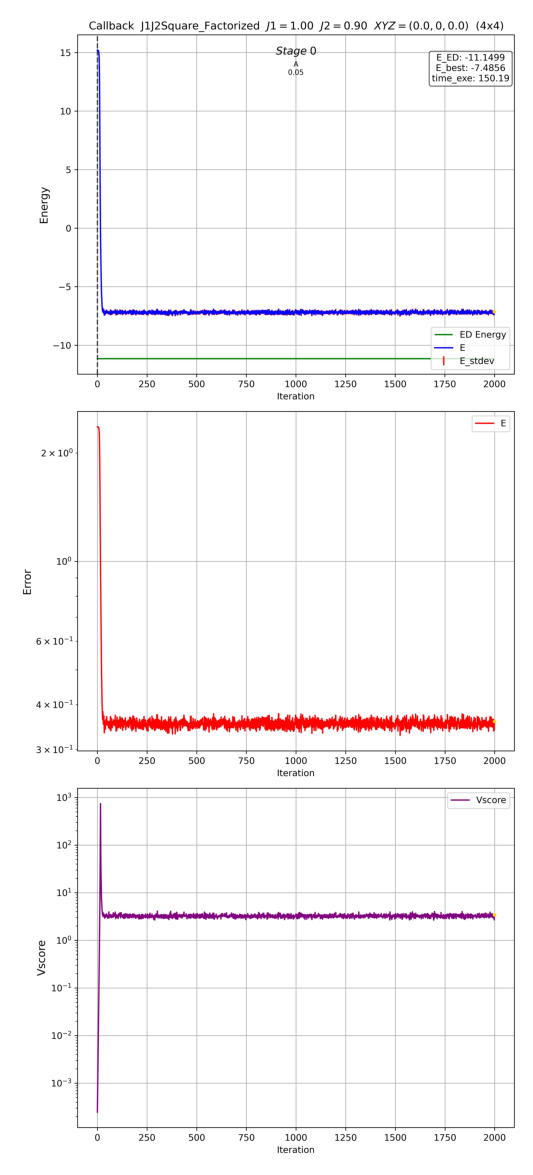

/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(




File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.9_XYZ_0.0_0.0_0.0_date_20260130T120159_UUID_a42c6714.json
{'Trans_0': {'phi': Array([-6.61143977,  6.6198155 , -6.6015239 ,  6.55499963, -6.57436348,
        6.60846355, -6.58415947,  6.71200708, -6.65483111,  6.57405074,
       -6.58554183,  6.54538401, -6.60646141,  6.60315297, -6.6594956 ,
        6.66606001], dtype=float64)}}
[[-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 0.0 (Stripped-VB)




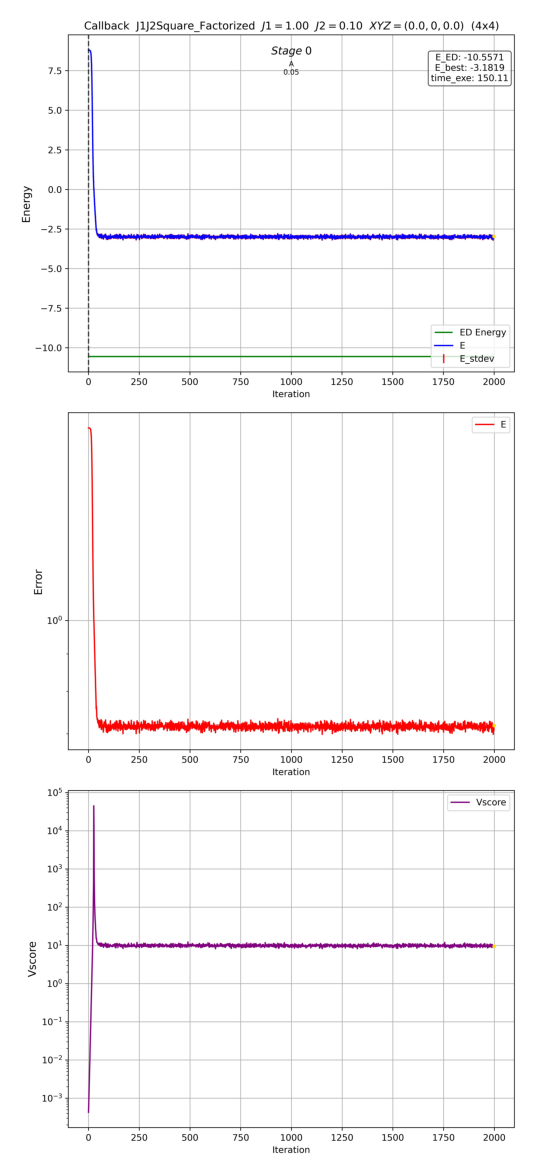



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.1_XYZ_0.0_0.0_0.0_date_20260130T111911_UUID_a42c6714.json
{'Trans_0': {'phi': Array([-6.28843136, -5.96785943,  6.57969331,  6.23747935,  6.48554892,
       -6.7298159 ,  5.34132179, -6.78139817, -6.61911973, -5.55215638,
        6.67712419,  6.26253231,  6.23441694,  6.72338439, -6.30395908,
       -6.29120564], dtype=float64)}}
[[-1 -1  1  1]
 [ 1 -1  1 -1]
 [-1 -1  1  1]
 [ 1  1 -1 -1]]


Distance with Neel:     12.0 (Neel-B)
Distance with Stripped: 12.0 (Stripped-VA)




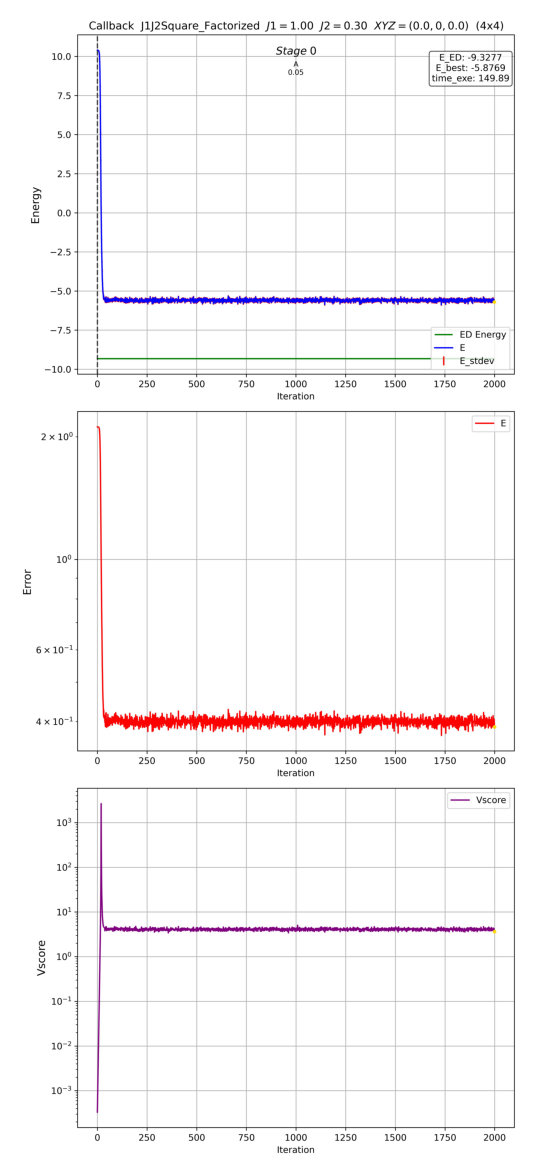



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.3_XYZ_0.0_0.0_0.0_date_20260130T112952_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.44945747, -6.41647469,  6.456333  , -6.43061926, -6.43894421,
        6.41217334, -6.4488943 ,  6.41511234,  6.45352779, -6.41723094,
        6.44256776, -6.43349123, -6.45618283,  6.4064391 , -6.42636375,
        6.4219513 ], dtype=float64)}}
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]]


Distance with Neel:     0 (Neel-A)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




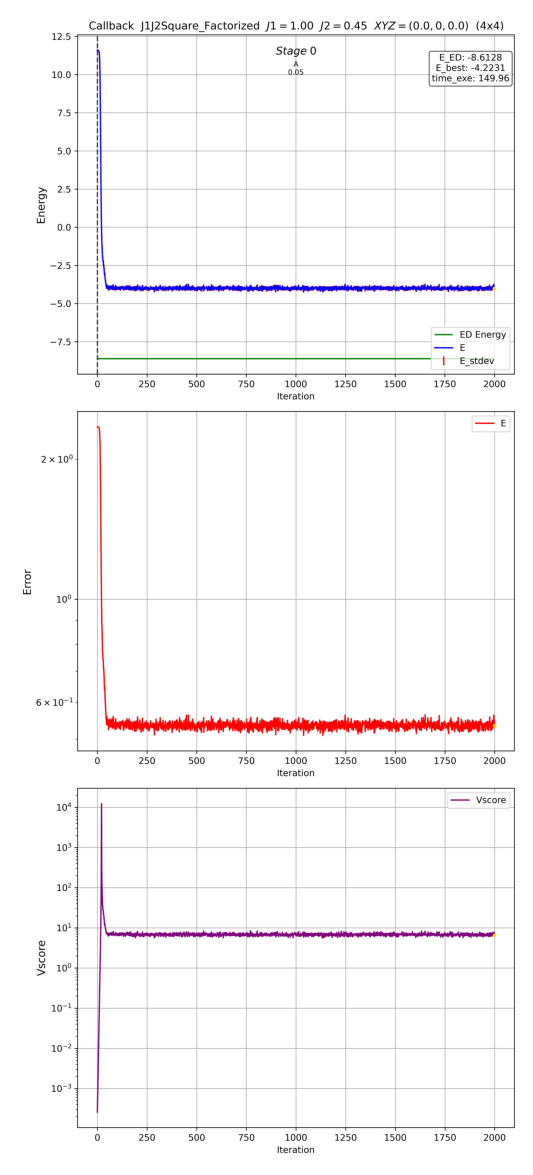



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.45_XYZ_0.0_0.0_0.0_date_20260130T113755_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.38740867, -6.52037775,  6.30502766, -6.67358088,  6.53427702,
       -6.29402883,  6.60934334, -6.28409232, -6.64502976,  6.35432679,
       -6.68075061,  6.33423078,  6.54255673, -6.29606653,  6.65219361,
       -6.27045775], dtype=float64)}}
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]]


Distance with Neel:     8.0 (Neel-B)
Distance with Stripped: 8.0 (Stripped-VA)




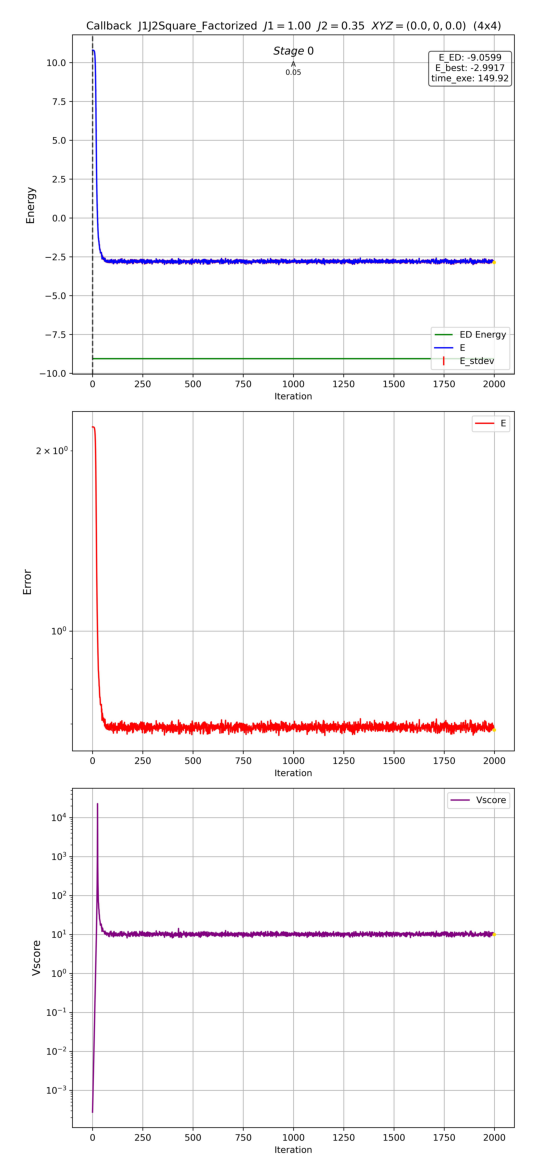



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.35_XYZ_0.0_0.0_0.0_date_20260130T113234_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.31261697, -6.38736381,  6.40659012, -6.65839814,  6.48221336,
       -6.28935527,  6.43484926, -6.15016323,  6.21679504, -6.40937941,
        6.26883164, -6.82334401,  6.62323973, -6.24475021,  6.45994447,
       -6.09646118], dtype=float64)}}
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 0.0 (Stripped-VA)




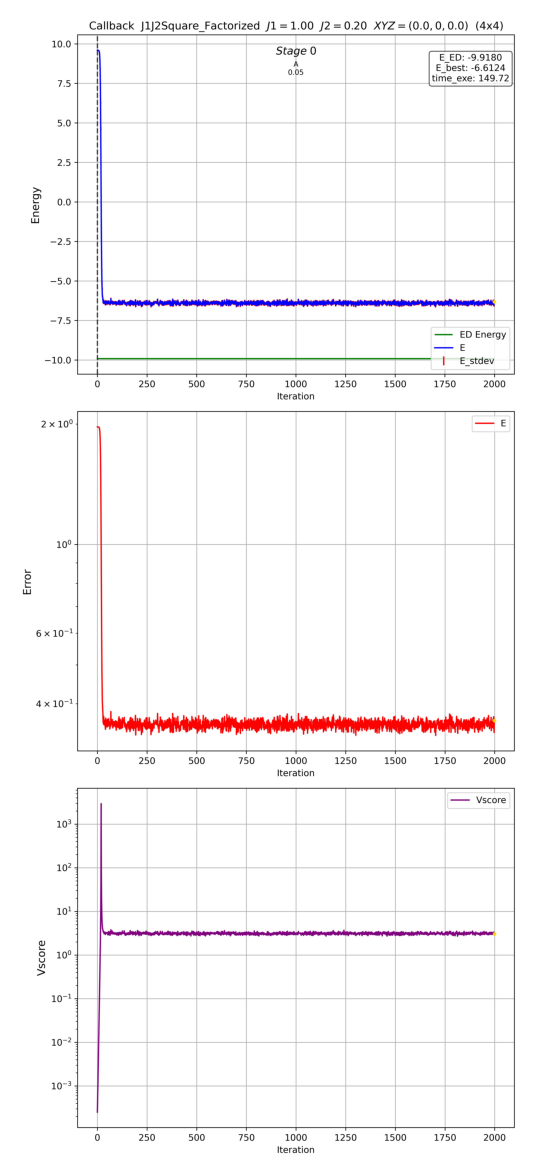



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.2_XYZ_0.0_0.0_0.0_date_20260130T112431_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.43475734, -6.42743127,  6.43350465, -6.43545538, -6.43507808,
        6.42597156, -6.43289177,  6.4320197 ,  6.43114971, -6.42777547,
        6.43380422, -6.42004368, -6.43876091,  6.42751338, -6.42437955,
        6.43450514], dtype=float64)}}
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]]


Distance with Neel:     0 (Neel-A)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




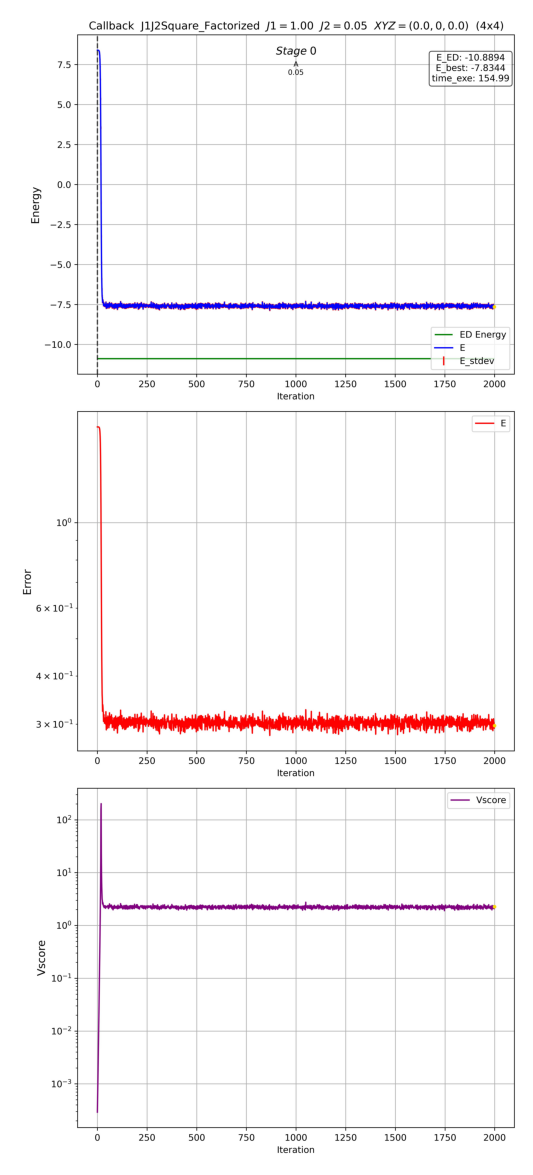



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.05_XYZ_0.0_0.0_0.0_date_20260130T111629_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.43014741, -6.43072527,  6.42825866, -6.43765481, -6.43084843,
        6.42834467, -6.43017977,  6.43253357,  6.43217081, -6.43414555,
        6.42830768, -6.43175291, -6.42523373,  6.4294158 , -6.43320608,
        6.42875619], dtype=float64)}}
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]]


Distance with Neel:     0 (Neel-A)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




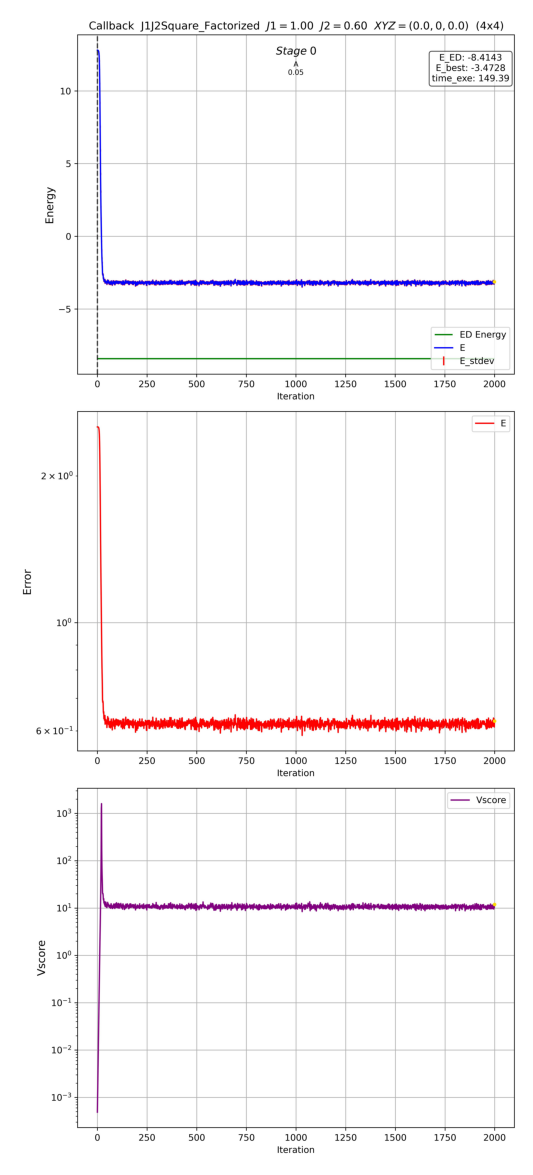



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.6_XYZ_0.0_0.0_0.0_date_20260130T114556_UUID_a42c6714.json
{'Trans_0': {'phi': Array([-8.50520931,  6.46232422, -8.54917283,  9.00700405, -6.11214569,
        6.38031591, -6.07059718, -5.83881146,  8.52915459, -6.31122724,
        8.52899355,  8.98334194, -8.9899345 ,  6.07789357, -8.96769279,
       -0.30489917], dtype=float64)}}
[[-1  1 -1  1]
 [-1  1 -1 -1]
 [ 1 -1  1  1]
 [-1  1 -1 -1]]


Distance with Neel:     14 (Neel-A)
Distance with Stripped: 10.0 (Stripped-VB-HA)




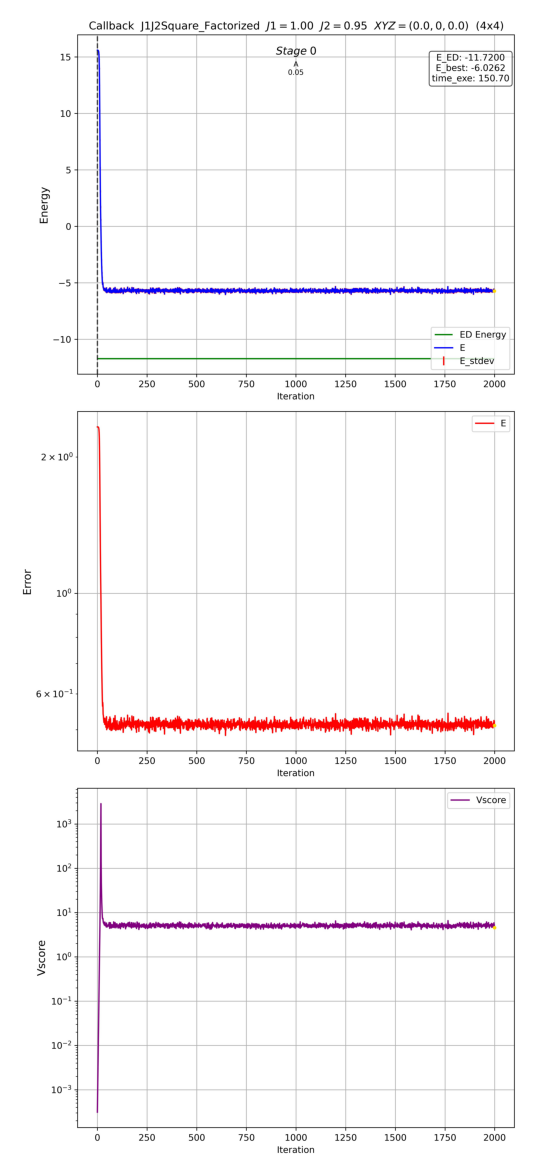



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.95_XYZ_0.0_0.0_0.0_date_20260130T120442_UUID_a42c6714.json
{'Trans_0': {'phi': Array([-6.91495663, -6.59392219, -6.88841138,  6.07467042,  6.43921809,
        6.61557819,  6.55681873,  6.36179774, -6.70008321, -6.68848392,
       -6.70190361, -6.76297433,  6.45327047,  6.63935647,  6.51318607,
        6.36038115], dtype=float64)}}
[[-1 -1 -1  1]
 [ 1  1  1  1]
 [-1 -1 -1 -1]
 [ 1  1  1  1]]


Distance with Neel:     14.0 (Neel-B)
Distance with Stripped: 2.0 (Stripped-HB)




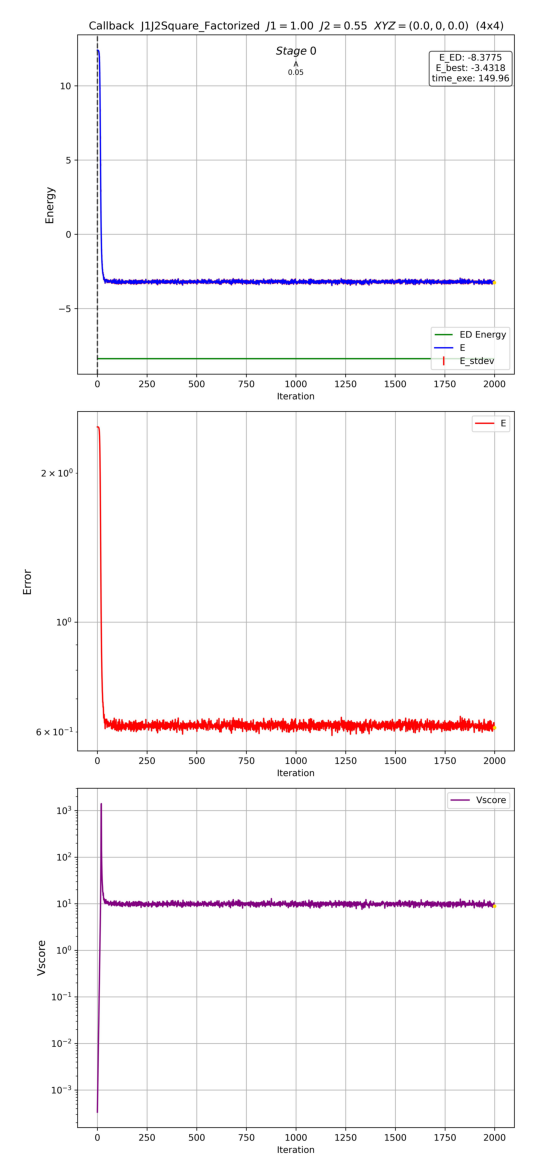



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.55_XYZ_0.0_0.0_0.0_date_20260130T114316_UUID_a42c6714.json
{'Trans_0': {'phi': Array([-6.41156628, -6.64050681,  6.20597253, -6.61037626,  6.62877221,
        6.28711696,  6.34084184,  6.2824041 , -6.662054  , -6.23663472,
       -6.68938534, -6.25593659,  6.44240717,  6.67664984, -5.89900951,
        6.67336259], dtype=float64)}}
[[-1 -1  1 -1]
 [ 1  1  1  1]
 [-1 -1 -1 -1]
 [ 1  1 -1  1]]


Distance with Neel:     12 (Neel-A)
Distance with Stripped: 4.0 (Stripped-HB)




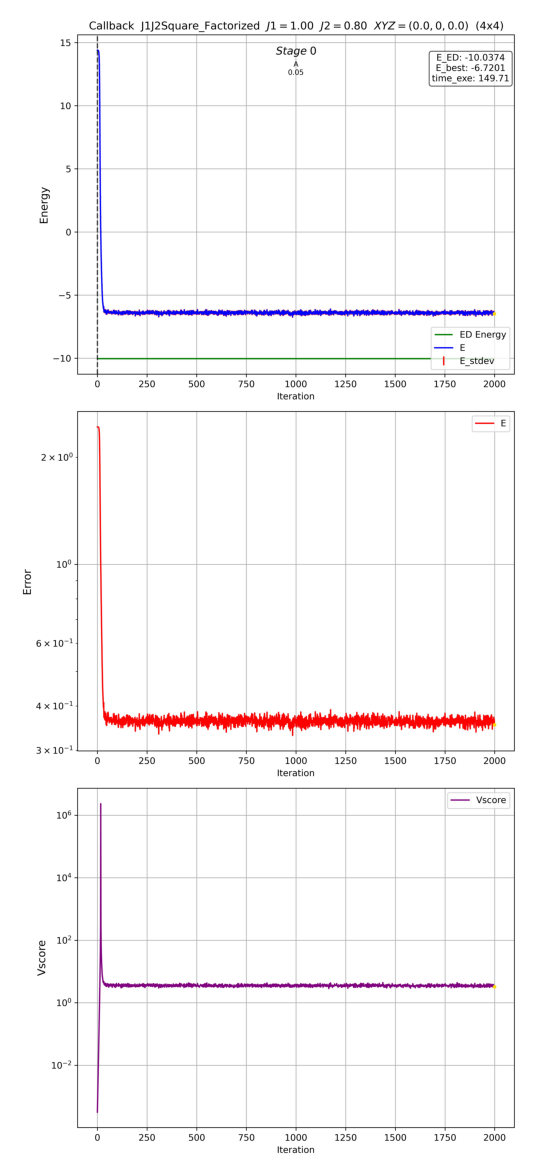



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.8_XYZ_0.0_0.0_0.0_date_20260130T115638_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.58088872, -6.71203487,  6.66769984, -6.63980515,  6.59721883,
       -6.47105701,  6.51539368, -6.49478927,  6.56393348, -6.72824435,
        6.60888912, -6.66471266,  6.60306815, -6.45637417,  6.55856805,
       -6.4777261 ], dtype=float64)}}
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 0.0 (Stripped-VA)




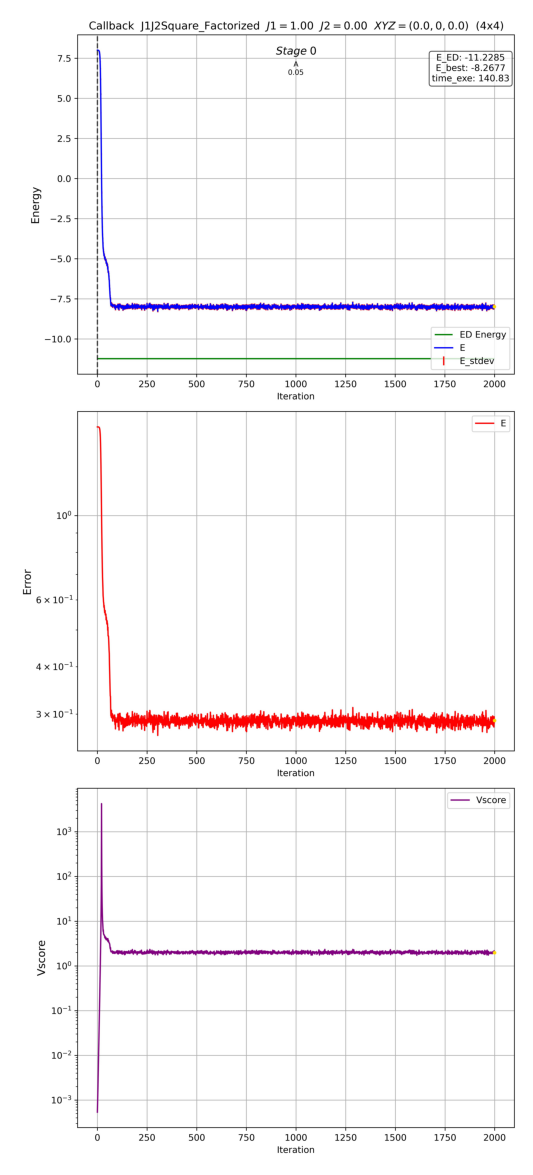



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260130T111335_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.46247961, -6.42286605,  6.47409023, -6.37698569, -6.42504566,
        6.4297287 , -6.42301163,  6.48445047,  6.4244606 , -6.43010973,
        6.41940377, -6.47052931, -6.46215469,  6.42022602, -6.47825467,
        6.39472802], dtype=float64)}}
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]]


Distance with Neel:     0 (Neel-A)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




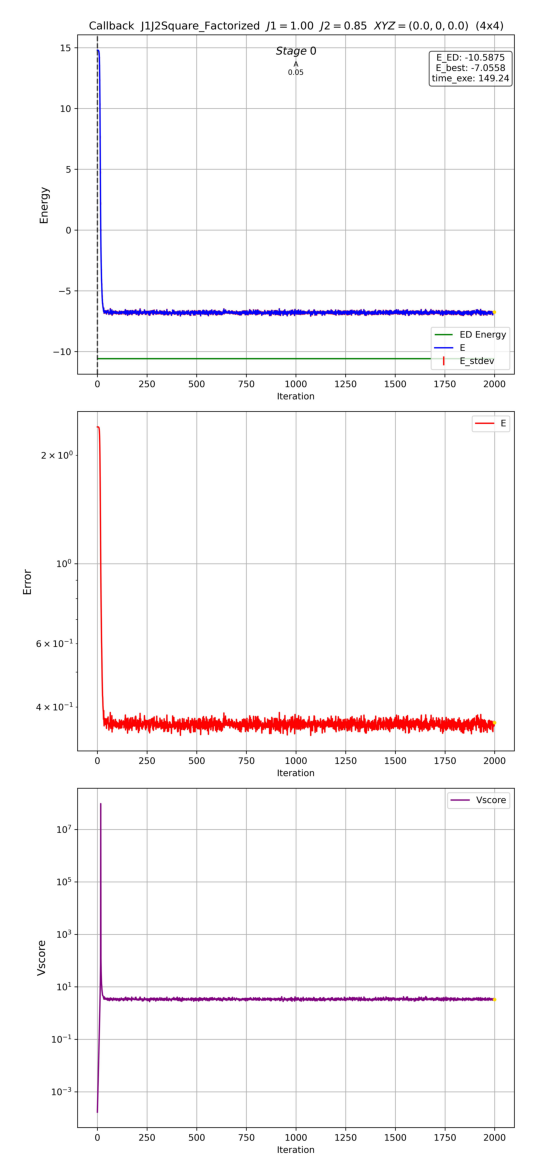



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.85_XYZ_0.0_0.0_0.0_date_20260130T115917_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.66344905, -6.64381477,  6.61270869, -6.57320526,  6.52730131,
       -6.56069321,  6.55179487, -6.60593488,  6.6852841 , -6.61908755,
        6.62230615, -6.60929499,  6.51610308, -6.54062185,  6.54245637,
       -6.58889197], dtype=float64)}}
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 0.0 (Stripped-VA)




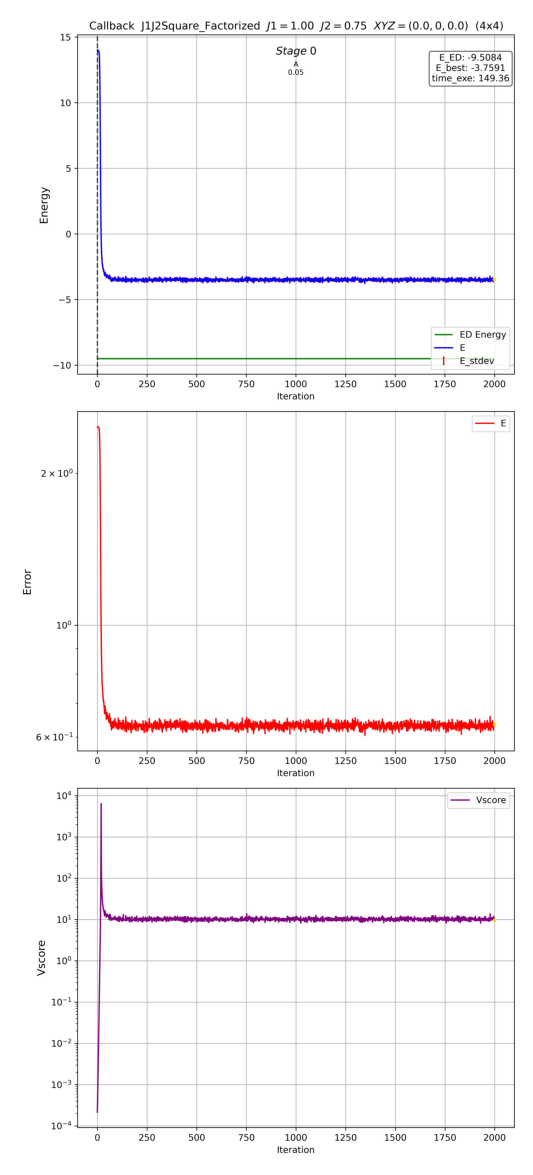



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.75_XYZ_0.0_0.0_0.0_date_20260130T115358_UUID_a42c6714.json
{'Trans_0': {'phi': Array([-6.56491911,  6.71552399, -6.76429262, -6.16361516, -6.49039957,
        6.49857195, -6.36448382,  6.85293562, -6.92003723,  6.5896389 ,
       -6.99467076,  5.79017268,  6.79944471, -6.00445163,  6.66585381,
        6.42254142], dtype=float64)}}
[[-1  1 -1 -1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [ 1 -1  1  1]]


Distance with Neel:     12.0 (Neel-B)
Distance with Stripped: 8.0 (Stripped-VB)




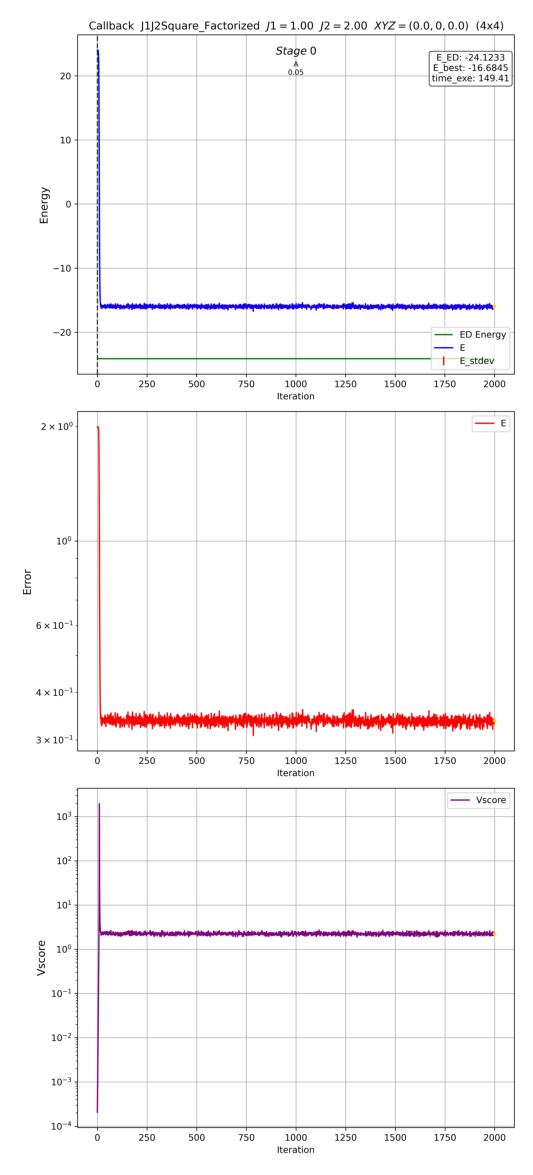



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_2.0_XYZ_0.0_0.0_0.0_date_20260130T121001_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.91669705, -6.89633264,  6.87614368, -6.88757676,  6.87602641,
       -6.89040667,  6.90977678, -6.90687837,  6.92400328, -6.89934787,
        6.87999856, -6.90105076,  6.87605381, -6.89688529,  6.9230512 ,
       -6.89192191], dtype=float64)}}
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 0.0 (Stripped-VA)




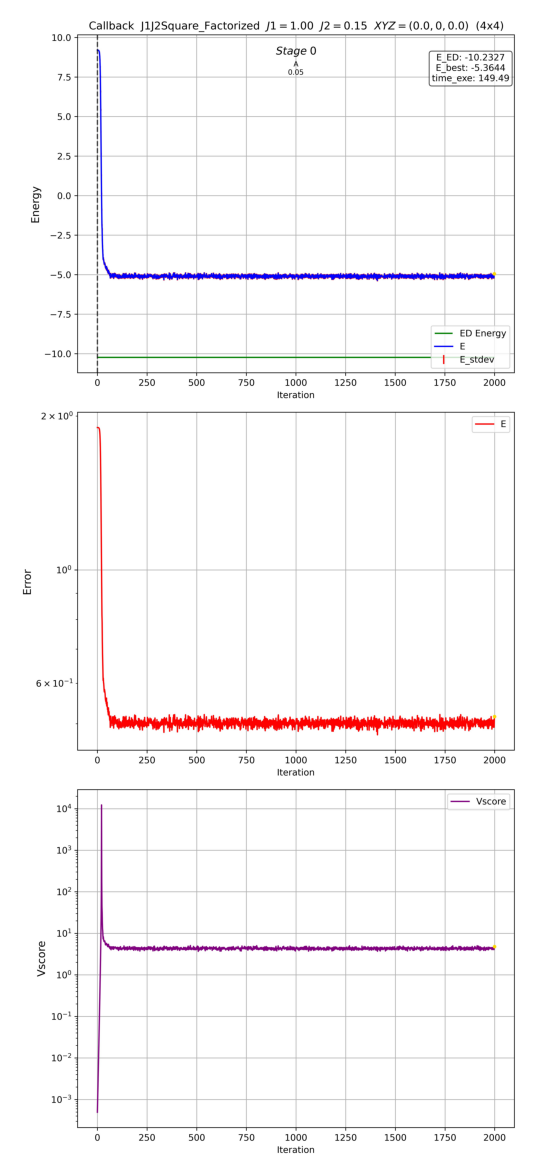



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.15_XYZ_0.0_0.0_0.0_date_20260130T112151_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.51072337, -6.3990498 ,  6.42959275, -6.39955748, -6.12314242,
        6.65244721, -6.42309034,  6.56141451, -6.21931546, -6.02714095,
        6.6789186 , -6.07630192, -6.18113782,  6.6048318 , -6.42427016,
        6.54474805], dtype=float64)}}
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [-1 -1  1 -1]
 [-1  1 -1  1]]


Distance with Neel:     2 (Neel-A)
Distance with Stripped: 14.0 (Stripped-VB-HB)




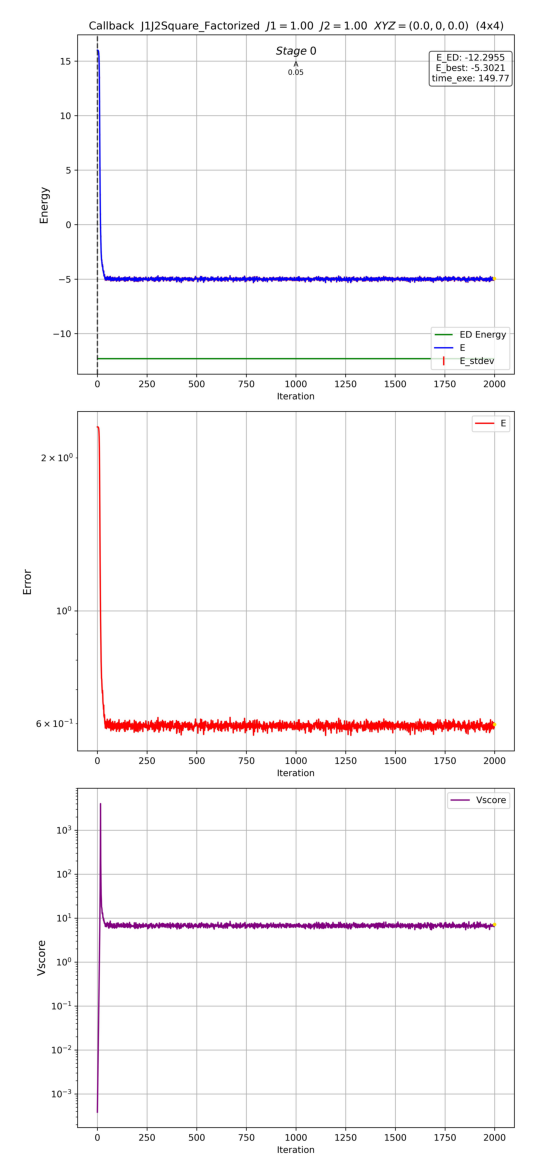



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_1.0_XYZ_0.0_0.0_0.0_date_20260130T120721_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.58607555,  6.80777206, -6.42203737,  6.81116608, -6.59383447,
       -6.74915768,  5.43960469, -6.74938447,  6.63326295,  6.73061286,
        6.5265229 ,  6.71562035, -6.63112319, -6.60443166, -6.38852659,
       -6.58676403], dtype=float64)}}
[[ 1  1 -1  1]
 [-1 -1  1 -1]
 [ 1  1  1  1]
 [-1 -1 -1 -1]]


Distance with Neel:     12.0 (Neel-B)
Distance with Stripped: 4.0 (Stripped-HA)




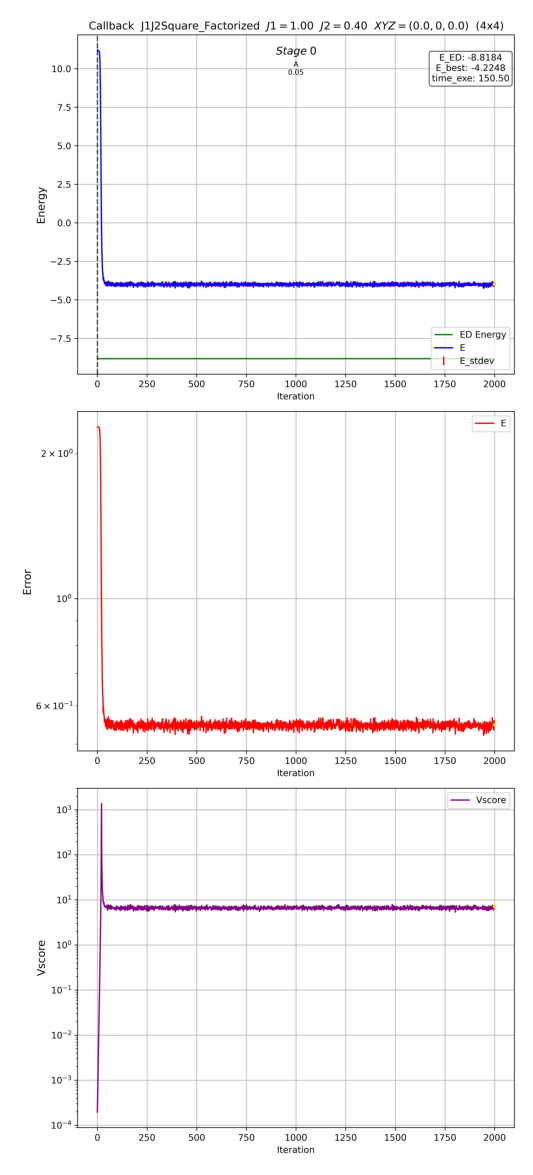



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.4_XYZ_0.0_0.0_0.0_date_20260130T113515_UUID_a42c6714.json
{'Trans_0': {'phi': Array([-6.4666455 ,  6.35664559, -6.56026157,  6.36979749, -6.27306373,
        6.46011924, -6.24077292,  6.46551244, -6.48739407,  6.40491133,
       -6.50879815,  6.38176536,  6.45872406, -6.3845669 ,  6.44357461,
       -6.40046522], dtype=float64)}}
[[-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]]


Distance with Neel:     8.0 (Neel-B)
Distance with Stripped: 8.0 (Stripped-VB)




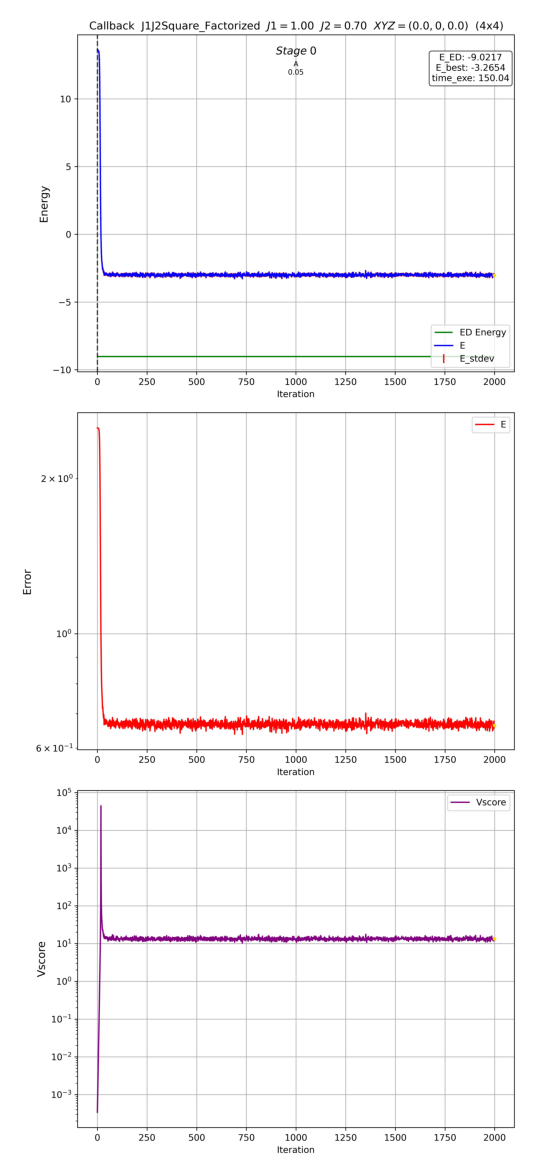



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.7_XYZ_0.0_0.0_0.0_date_20260130T115117_UUID_a42c6714.json
{'Trans_0': {'phi': Array([-6.39973544,  6.30255033, -6.29425253,  6.36487621,  6.44690261,
       -6.80424738,  6.98752877, -6.91245525,  5.84453714, -6.67416614,
       -5.42882795,  6.63775262, -6.67996027,  6.96215948, -6.93694246,
        6.78212548], dtype=float64)}}
[[-1  1 -1  1]
 [ 1 -1  1 -1]
 [ 1 -1 -1  1]
 [-1  1 -1  1]]


Distance with Neel:     12.0 (Neel-B)
Distance with Stripped: 12.0 (Stripped-VB)




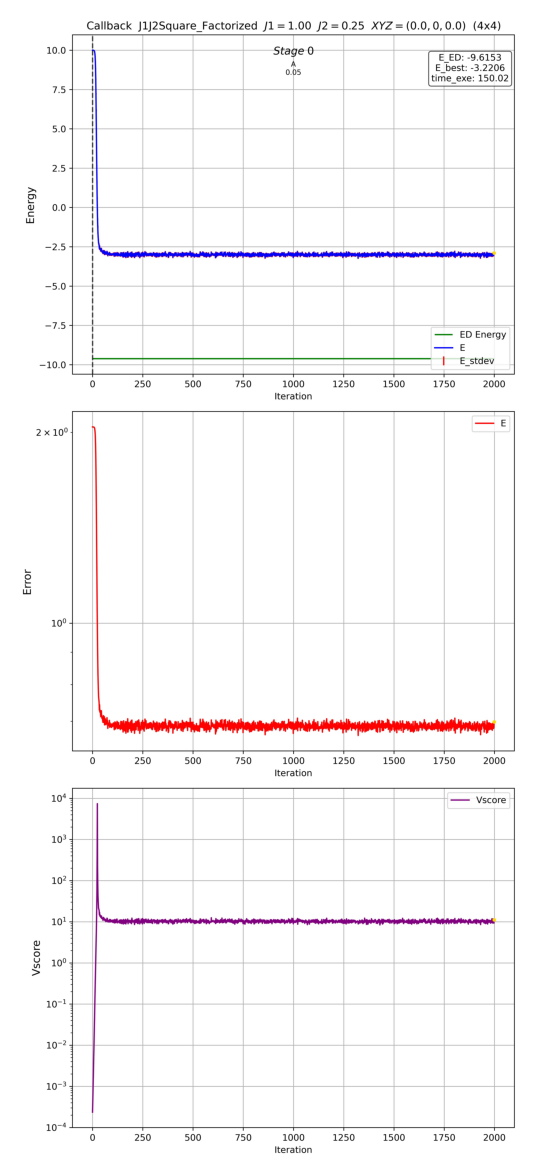



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.25_XYZ_0.0_0.0_0.0_date_20260130T112712_UUID_a42c6714.json
{'Trans_0': {'phi': Array([-6.09701013,  6.58046674, -6.4738716 ,  6.33157115,  6.84277421,
       -6.58643923,  6.17082389, -6.48404652,  5.62989439,  6.72819839,
        6.23800838, -6.72568002, -6.7245395 , -6.29945688, -5.91205629,
        6.57334204], dtype=float64)}}
[[-1  1 -1  1]
 [ 1 -1  1 -1]
 [ 1  1  1 -1]
 [-1 -1 -1  1]]


Distance with Neel:     12.0 (Neel-B)
Distance with Stripped: 12.0 (Stripped-HA)




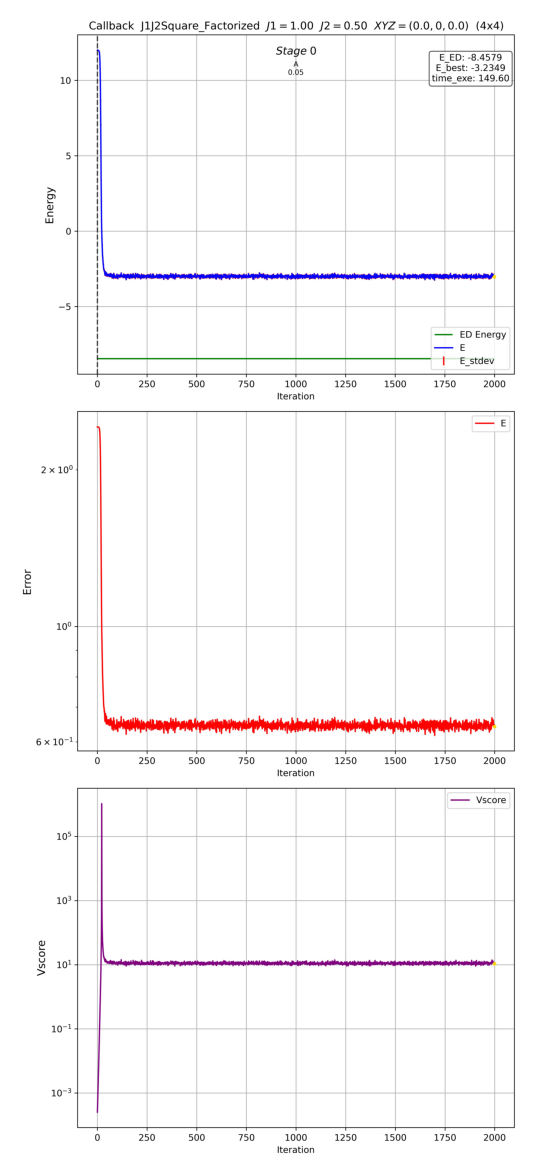



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.5_XYZ_0.0_0.0_0.0_date_20260130T114036_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.38925693,  6.60398676, -6.63920792,  6.48651755, -6.38370723,
       -6.38077317,  6.13809752, -6.56576303,  6.67561416, -6.21680441,
        6.62773967,  6.10096921, -6.35673641, -6.23370129,  6.24809652,
       -6.58070295], dtype=float64)}}
[[ 1  1 -1  1]
 [-1 -1  1 -1]
 [ 1 -1  1  1]
 [-1 -1  1 -1]]


Distance with Neel:     12.0 (Neel-B)
Distance with Stripped: 8.0 (Stripped-HA)




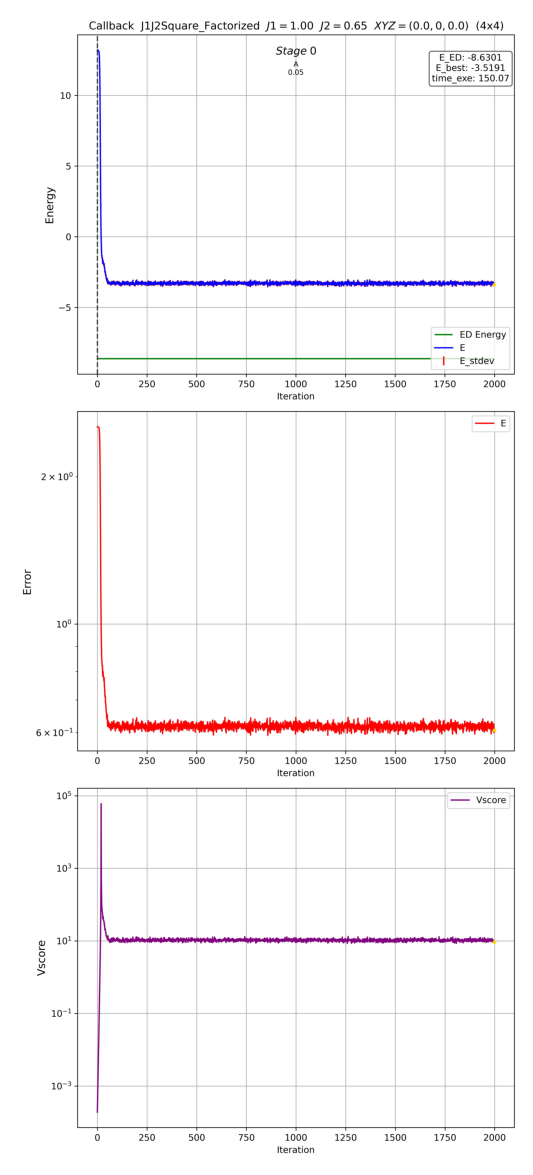



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_a42c6714/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.65_XYZ_0.0_0.0_0.0_date_20260130T114837_UUID_a42c6714.json
{'Trans_0': {'phi': Array([ 6.84819375, -5.8159857 ,  6.84551615, -6.51264746,  6.31981387,
       -6.89039493,  6.33029867, -6.70428521,  6.70829927,  6.10613902,
        6.70273284, -6.34224658, -6.70600226, -6.31872793, -6.68909095,
        6.18683633], dtype=float64)}}
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1  1  1 -1]
 [-1 -1 -1  1]]


Distance with Neel:     12 (Neel-A)
Distance with Stripped: 8.0 (Stripped-VA)




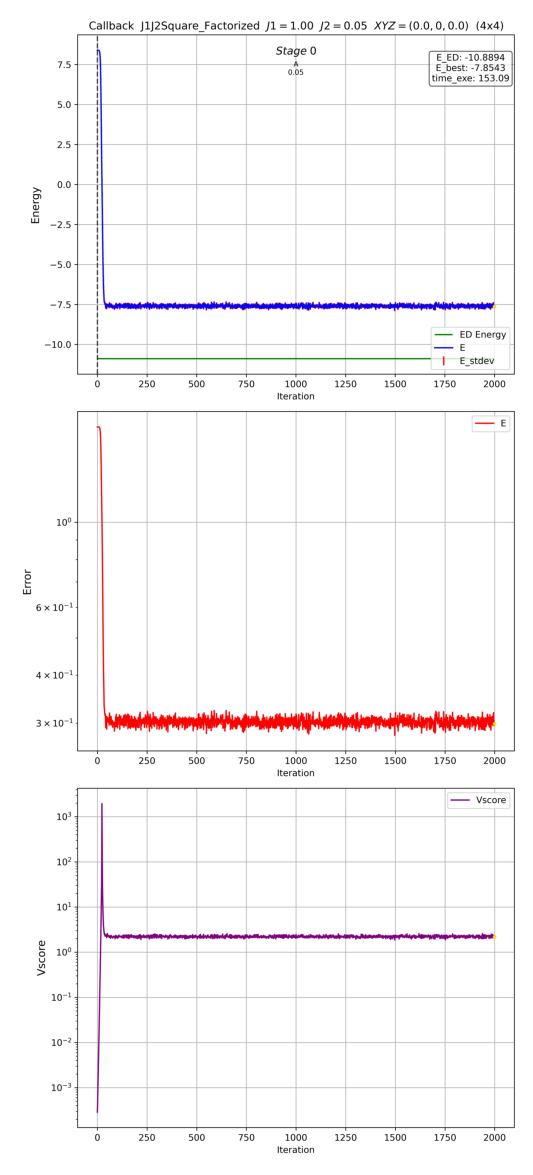



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.05_XYZ_0.0_0.0_0.0_date_20260130T111635_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 6.44419638, -6.42536254,  6.42247675, -6.42358347, -6.41447637,
        6.41843465, -6.43158743,  6.4305024 ,  6.4355167 , -6.43895158,
        6.43327255, -6.43675268, -6.4290925 ,  6.43303565, -6.43245191,
        6.4379773 ], dtype=float64)}}
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]]


Distance with Neel:     0 (Neel-A)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




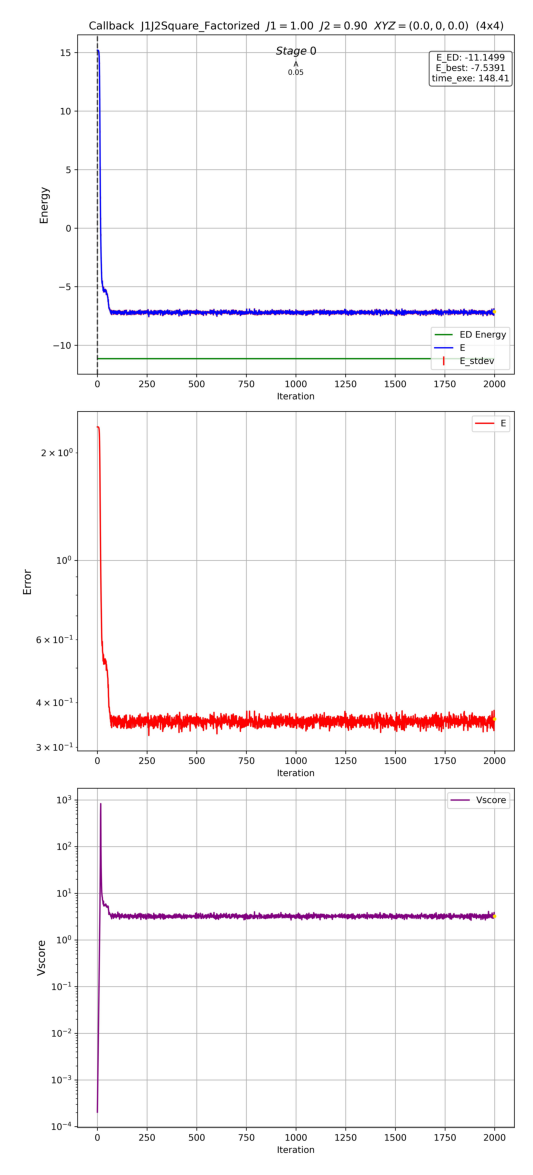



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.9_XYZ_0.0_0.0_0.0_date_20260130T120124_UUID_9366a696.json
{'Trans_0': {'phi': Array([-6.72595474,  6.58181071, -6.55055482,  6.63824306, -6.4851636 ,
        6.74238068, -6.61466321,  6.64597411, -6.78812758,  6.55545832,
       -6.56585098,  6.58369004, -6.55857639,  6.66461156, -6.71308146,
        6.58946972], dtype=float64)}}
[[-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 0.0 (Stripped-VB)




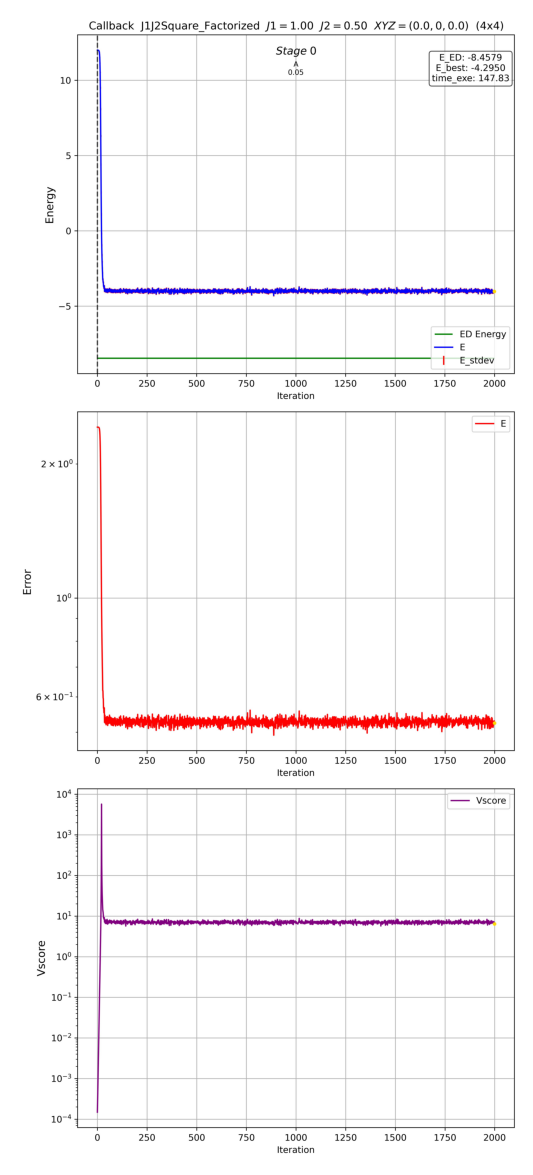



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.5_XYZ_0.0_0.0_0.0_date_20260130T114018_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 6.46763909, -6.5466579 ,  6.44503989, -6.44721742, -6.36493466,
        6.35481724, -6.40298725,  6.51755961, -6.53497976,  6.54431197,
       -6.46041136,  6.34835921, -6.39322764,  6.35338553, -6.39691213,
        6.50619237], dtype=float64)}}
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]]


Distance with Neel:     8 (Neel-A)
Distance with Stripped: 8.0 (Stripped-VB)




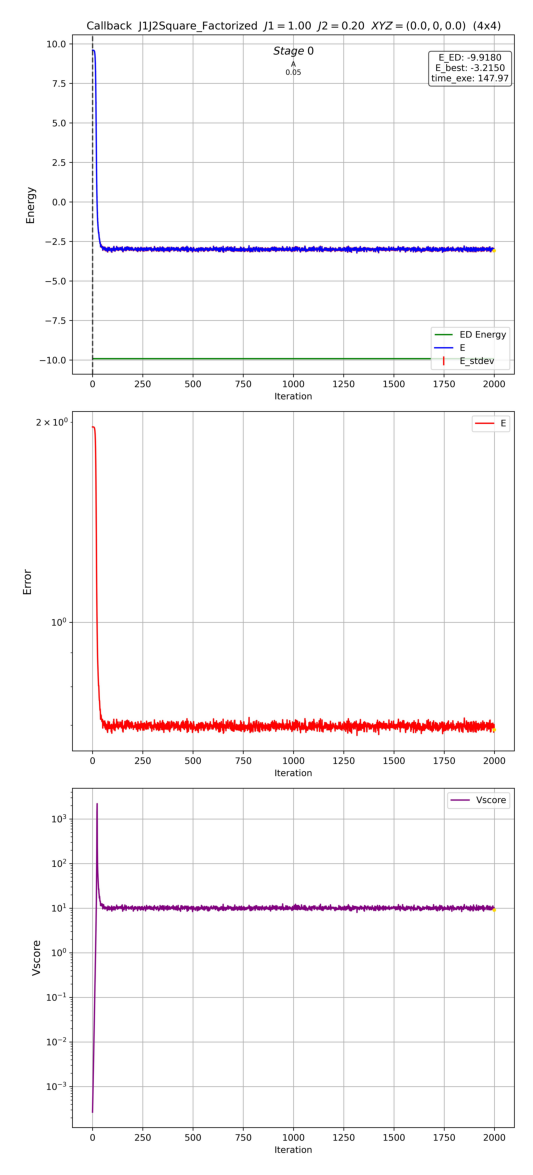



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.2_XYZ_0.0_0.0_0.0_date_20260130T112431_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 5.55304205, -6.6228592 , -6.28100432,  6.57928752, -6.56995258,
        6.56208022,  6.31866268, -6.23773369, -5.99812354, -5.96282934,
       -6.53090522,  6.54832308,  6.46918708,  6.18095232,  6.39488302,
       -6.48872772], dtype=float64)}}
[[ 1 -1 -1  1]
 [-1  1  1 -1]
 [-1 -1 -1  1]
 [ 1  1  1 -1]]


Distance with Neel:     12.0 (Neel-B)
Distance with Stripped: 12.0 (Stripped-HB)




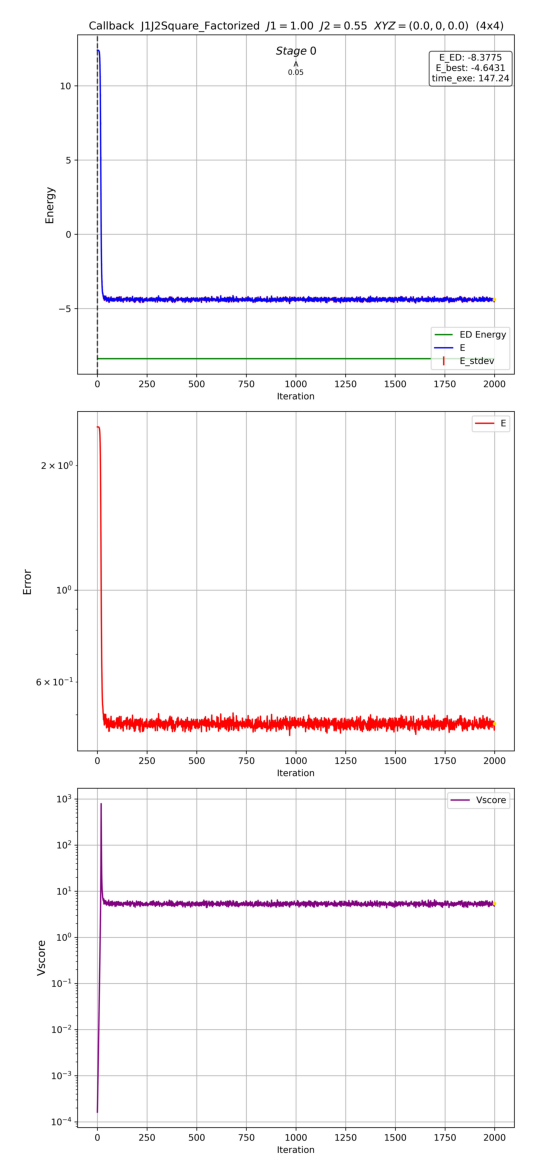



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.55_XYZ_0.0_0.0_0.0_date_20260130T114256_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 6.44580732, -6.51817386,  6.45811857, -6.39781495,  6.4530743 ,
       -6.42517606,  6.48188455, -6.48682168,  6.46294528, -6.50548163,
        6.41398658, -6.43237884,  6.47916206, -6.39658282,  6.48648174,
       -6.51989729], dtype=float64)}}
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 0.0 (Stripped-VA)




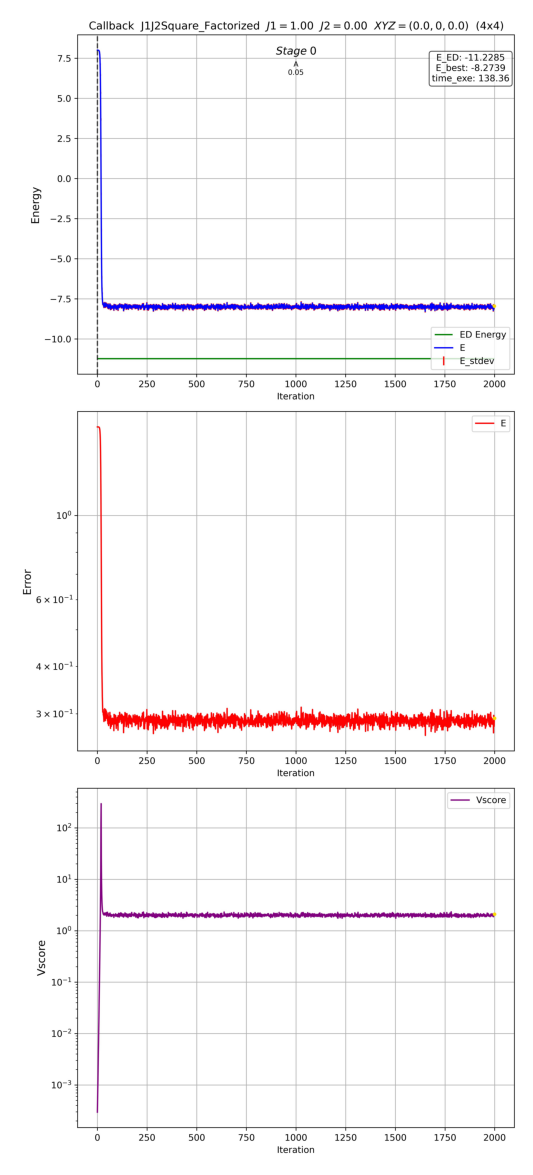



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260130T111344_UUID_9366a696.json
{'Trans_0': {'phi': Array([-6.4297568 ,  6.43144719, -6.43092782,  6.43138666,  6.42852561,
       -6.43150713,  6.42986917, -6.42770287, -6.43183245,  6.42692584,
       -6.43163238,  6.43080462,  6.42983621, -6.42742613,  6.42545686,
       -6.43838986], dtype=float64)}}
[[-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]]


Distance with Neel:     0.0 (Neel-B)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




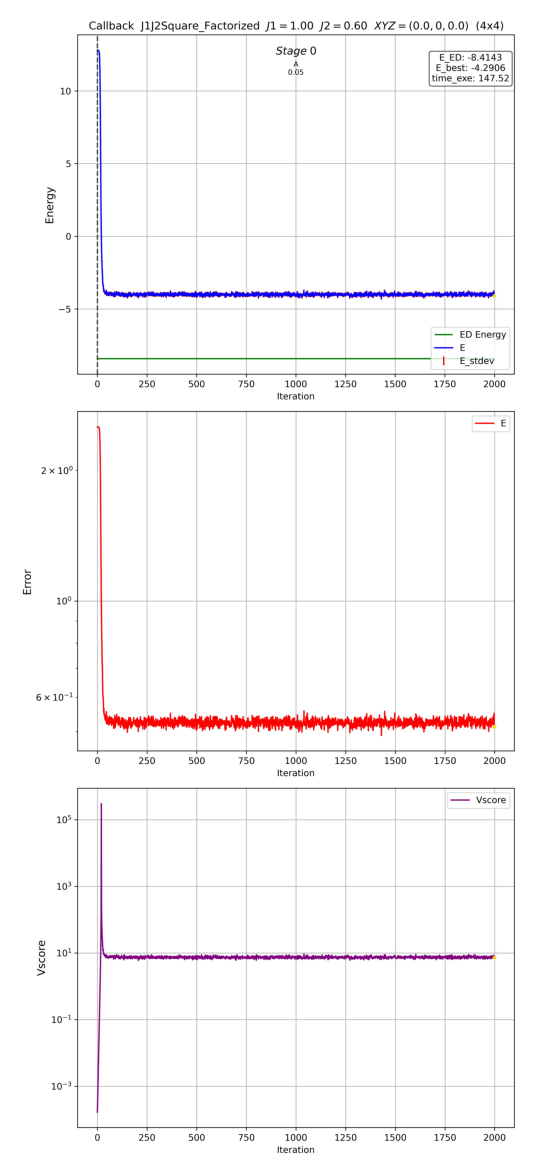



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.6_XYZ_0.0_0.0_0.0_date_20260130T114535_UUID_9366a696.json
{'Trans_0': {'phi': Array([-6.43312417,  6.55792652, -6.49492314,  6.60733443,  6.33837128,
       -6.4883053 ,  6.37944272, -6.4707273 ,  6.60186336, -6.5083679 ,
        6.51460491, -6.53834938, -6.46301143,  6.38410361, -6.39552704,
        6.3675315 ], dtype=float64)}}
[[-1  1 -1  1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




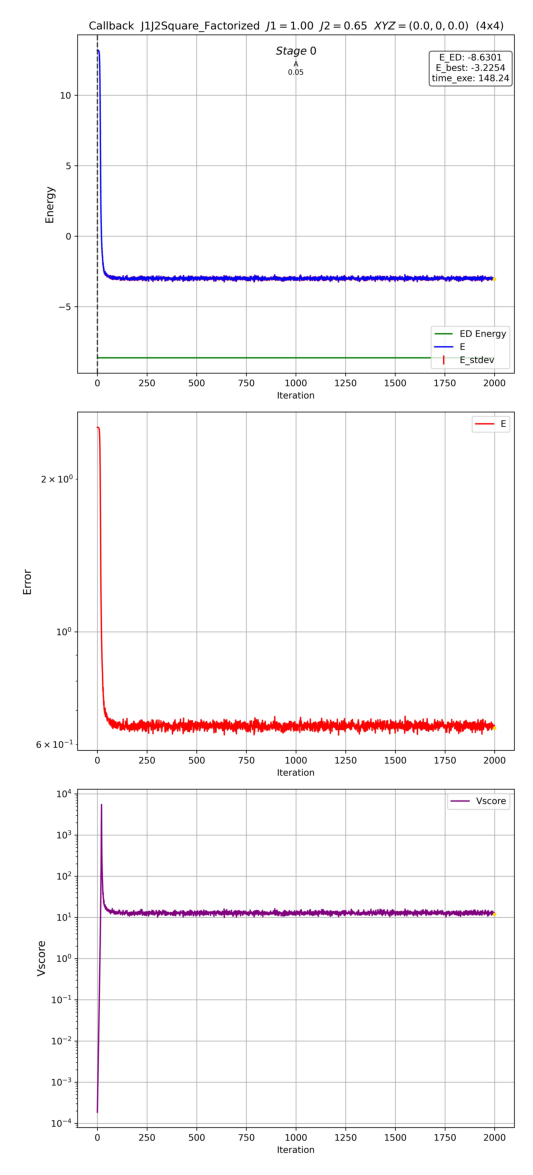



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.65_XYZ_0.0_0.0_0.0_date_20260130T114813_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 6.78564377, -5.84315978,  6.98559458, -5.79973449, -6.99540486,
        6.59074658, -6.97843969,  6.65633017, -6.34388398,  6.16704454,
        6.24882633,  6.19383849,  6.92385284, -6.76512075, -6.60823067,
       -6.86397174], dtype=float64)}}
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [-1  1  1  1]
 [ 1 -1 -1 -1]]


Distance with Neel:     12 (Neel-A)
Distance with Stripped: 12.0 (Stripped-HA)




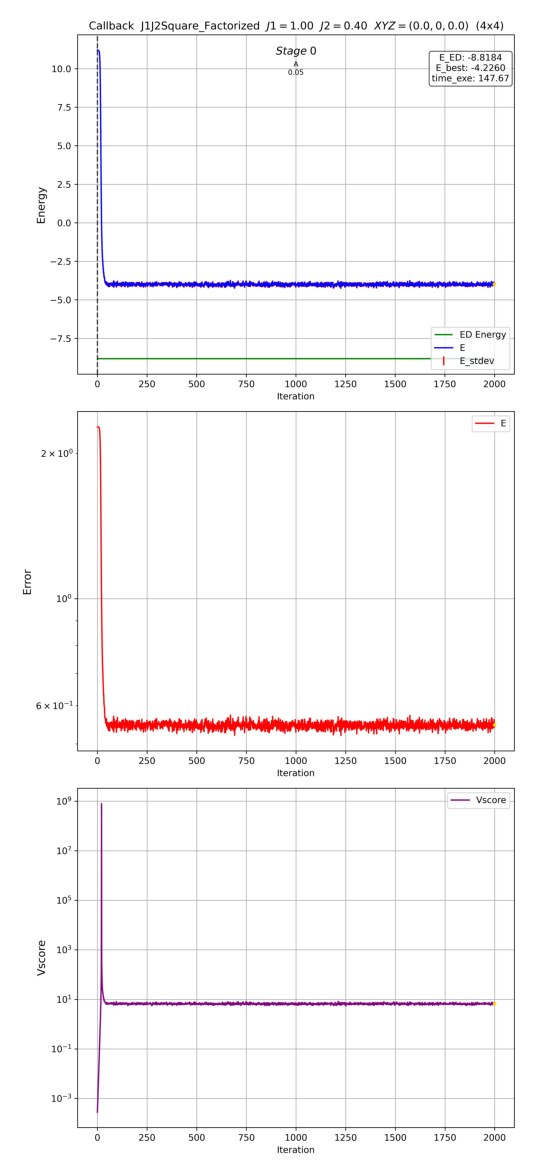



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.4_XYZ_0.0_0.0_0.0_date_20260130T113503_UUID_9366a696.json
{'Trans_0': {'phi': Array([-6.46748693,  6.47294378, -6.4641822 ,  6.46770692,  6.36063344,
       -6.39847841,  6.38539382, -6.40249133,  6.44019902, -6.41288984,
        6.46512195, -6.31517686,  6.38223467, -6.34931469,  6.33709337,
       -6.48804472], dtype=float64)}}
[[-1  1 -1  1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]]


Distance with Neel:     8.0 (Neel-B)
Distance with Stripped: 8.0 (Stripped-VA)




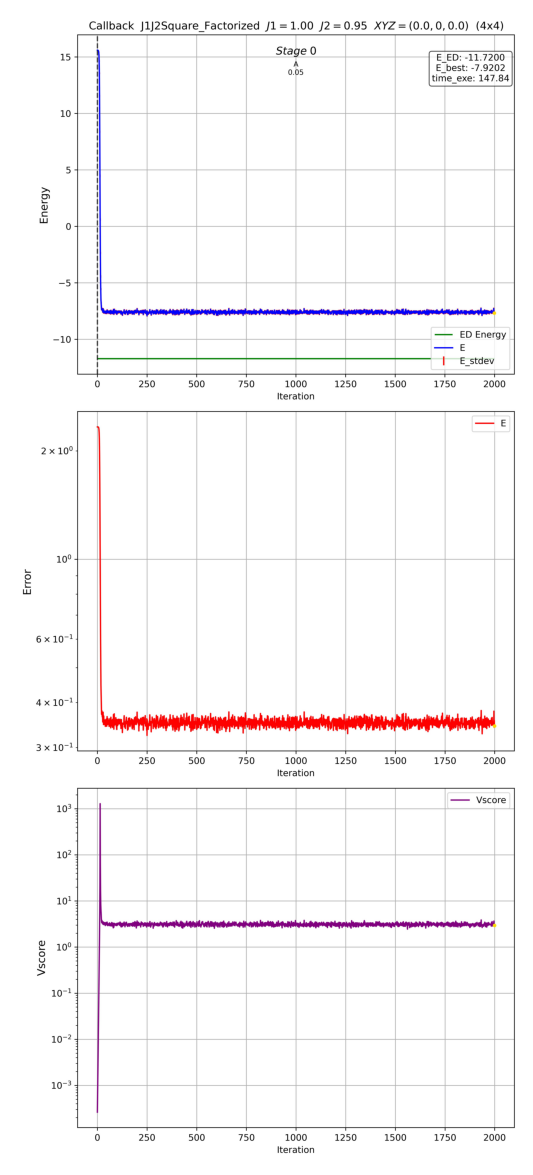



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.95_XYZ_0.0_0.0_0.0_date_20260130T120402_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 6.61753101, -6.59495767,  6.65292447, -6.67043433,  6.63775049,
       -6.66159534,  6.59320731, -6.59083429,  6.61367946, -6.58769008,
        6.66038175, -6.63389054,  6.62542333, -6.64549716,  6.60082149,
       -6.58435713], dtype=float64)}}
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 0.0 (Stripped-VA)




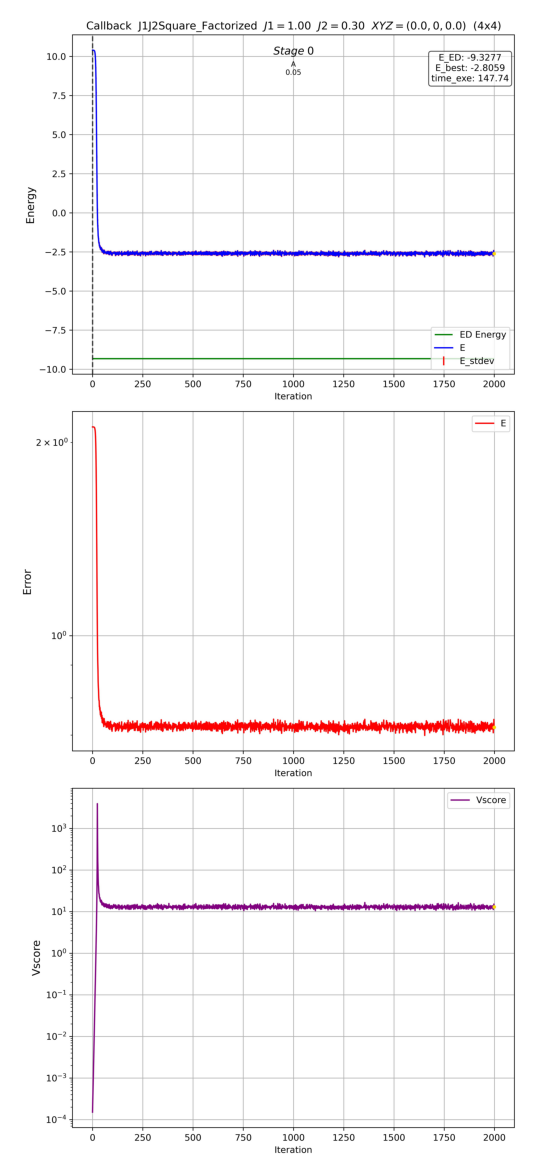



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.3_XYZ_0.0_0.0_0.0_date_20260130T112947_UUID_9366a696.json
{'Trans_0': {'phi': Array([-6.30498898,  6.75743379,  5.88490488,  6.55444127,  6.17354791,
       -6.60525408, -6.20852398, -6.58447303,  6.35271702,  6.22112037,
        6.47114817, -6.21595499, -6.09092159, -6.27758249, -6.64543686,
        6.44080632], dtype=float64)}}
[[-1  1  1  1]
 [ 1 -1 -1 -1]
 [ 1  1  1 -1]
 [-1 -1 -1  1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 8.0 (Stripped-HA)




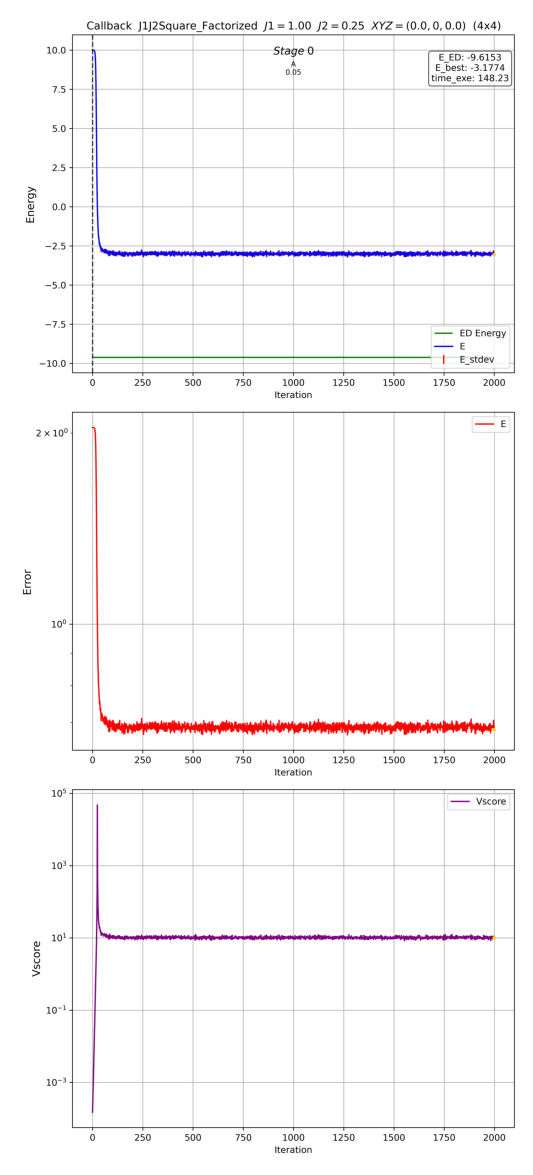



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.25_XYZ_0.0_0.0_0.0_date_20260130T112709_UUID_9366a696.json
{'Trans_0': {'phi': Array([-5.69124581,  6.78434496, -6.42491948,  6.67482556, -6.81216959,
        6.46146372, -6.28036587,  6.41731794,  6.4197402 , -6.34982429,
        6.23631864, -6.60371589, -6.83416079, -5.98995989,  6.39280323,
        5.8572156 ], dtype=float64)}}
[[-1  1 -1  1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1 -1  1  1]]


Distance with Neel:     12 (Neel-A)
Distance with Stripped: 12.0 (Stripped-VB)




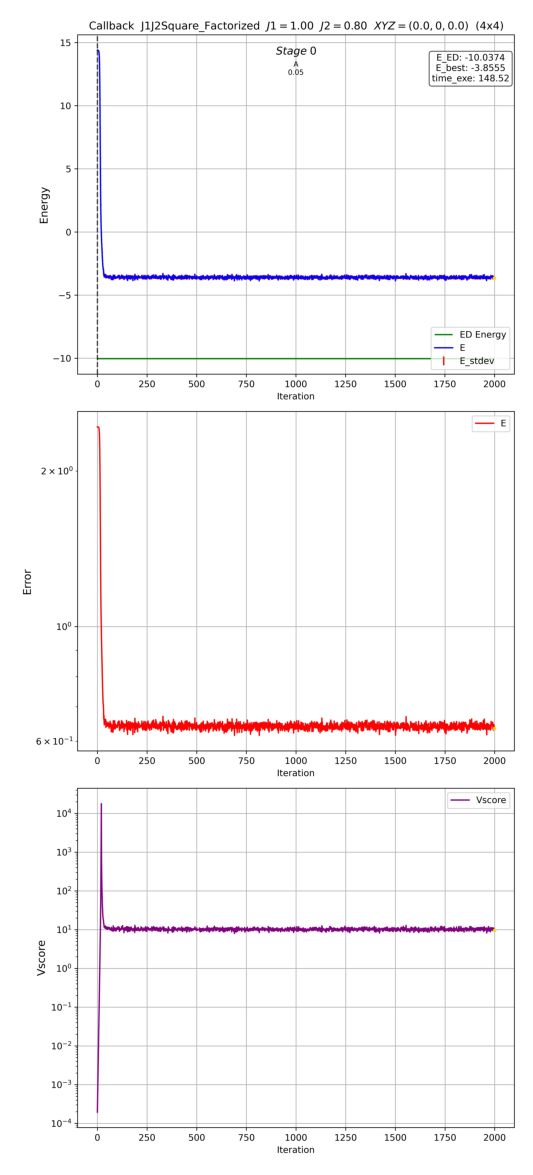



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.8_XYZ_0.0_0.0_0.0_date_20260130T115608_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 8.99092299,  8.79017072,  6.57020595, -8.8270004 , -6.08183662,
       -6.52878456, -6.22199745,  6.17268584,  8.97769766,  8.81708605,
        6.42276169, -8.83438978,  0.56443736, -9.01100003,  5.34331129,
       -8.97990591], dtype=float64)}}
[[ 1  1  1 -1]
 [-1 -1 -1  1]
 [ 1  1  1 -1]
 [ 1 -1  1 -1]]


Distance with Neel:     14 (Neel-A)
Distance with Stripped: 10.0 (Stripped-VA-HA)




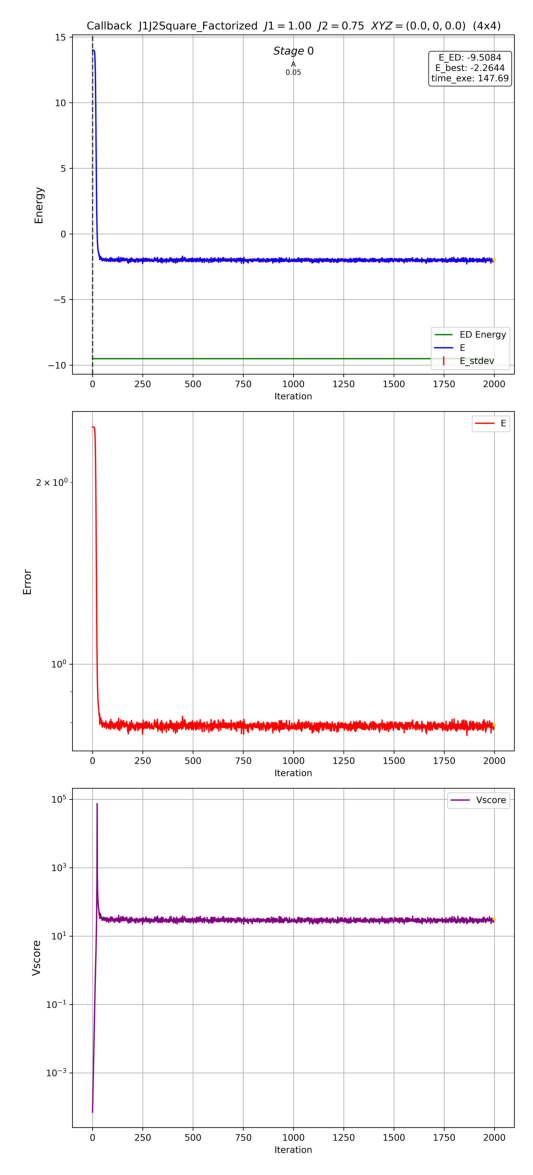



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.75_XYZ_0.0_0.0_0.0_date_20260130T115330_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 8.59759309,  8.8763313 , -8.68486791,  6.33352836, -6.50250227,
        6.14839596,  5.59249241,  6.37840824,  8.63473973, -8.8880249 ,
       -8.64610057, -6.1993512 , -8.89306382, -0.82084144,  8.90794787,
       -5.6310319 ], dtype=float64)}}
[[ 1  1 -1  1]
 [-1  1  1  1]
 [ 1 -1 -1 -1]
 [-1 -1  1 -1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




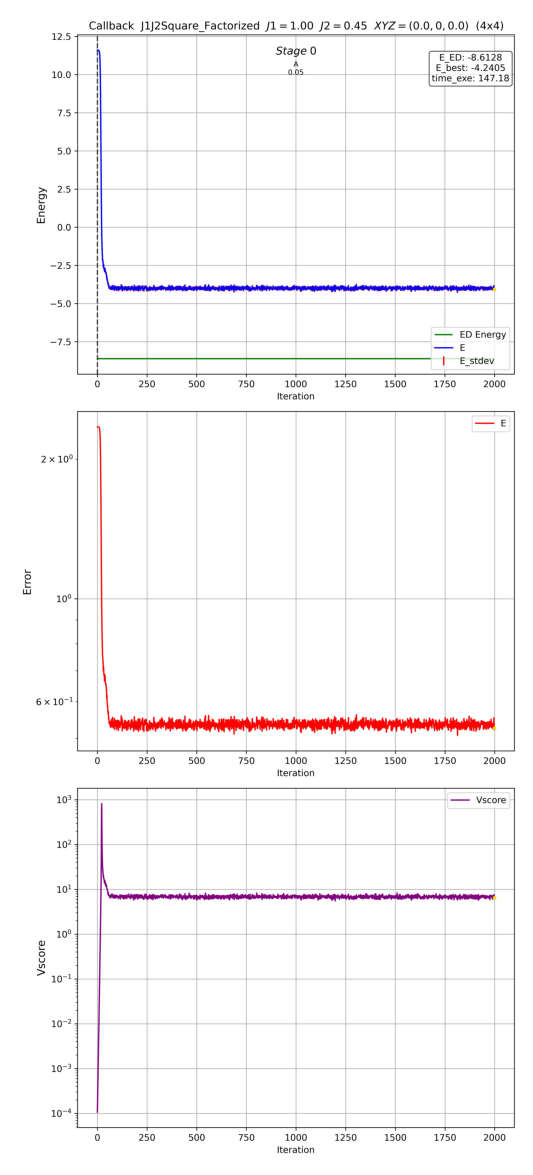



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.45_XYZ_0.0_0.0_0.0_date_20260130T113740_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 6.44613047, -6.61406825,  6.5892609 , -6.42593576, -6.42571889,
        6.30553051, -6.32976151,  6.45259392, -6.36992798,  6.68916872,
       -6.6730682 ,  6.30493526, -6.53968361,  6.26629876, -6.27990867,
        6.58666729], dtype=float64)}}
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]]


Distance with Neel:     8 (Neel-A)
Distance with Stripped: 8.0 (Stripped-VB)




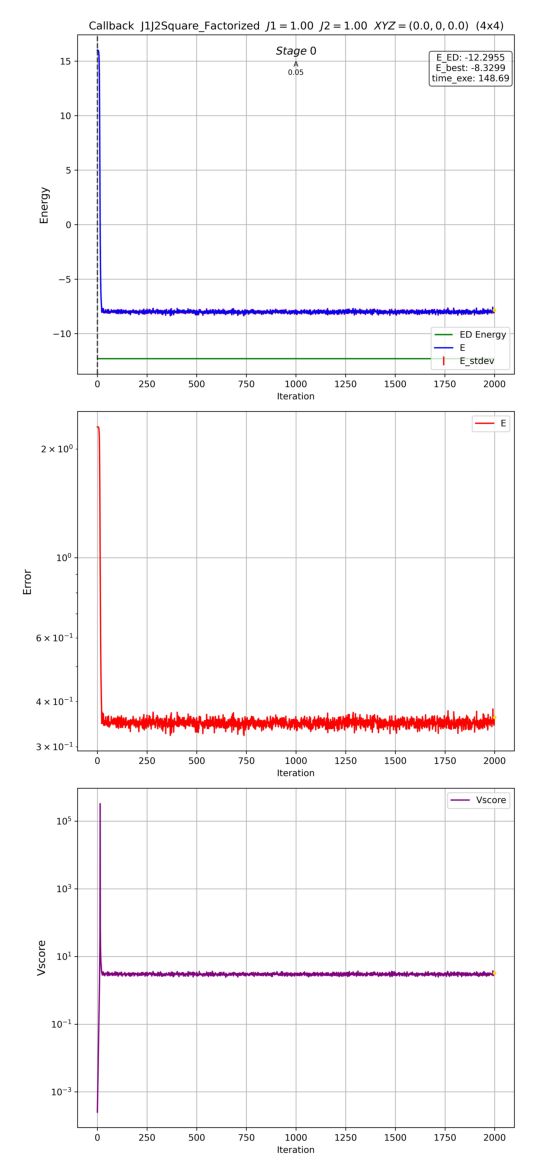



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_1.0_XYZ_0.0_0.0_0.0_date_20260130T120642_UUID_9366a696.json
{'Trans_0': {'phi': Array([-6.67940522,  6.63250915, -6.60496692,  6.65572443, -6.59344839,
        6.65961154, -6.67806364,  6.63046829, -6.68931821,  6.62144888,
       -6.60819949,  6.67962177, -6.60030351,  6.64931745, -6.67878379,
        6.60757982], dtype=float64)}}
[[-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]]


Distance with Neel:     16 (Same in Neel-A and Neel-B)
Distance with Stripped: 0.0 (Stripped-VB)




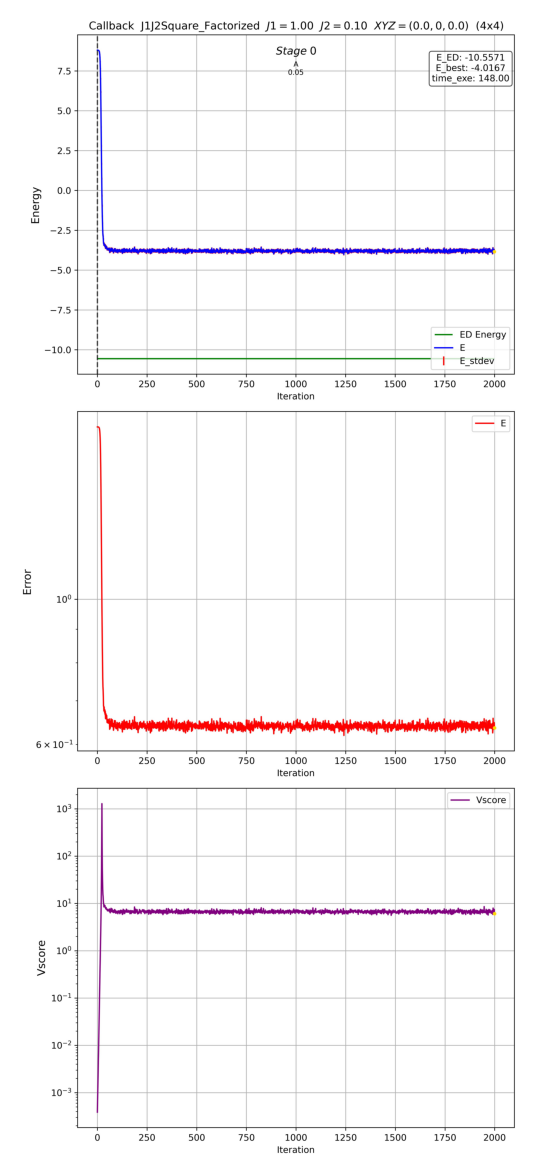



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.1_XYZ_0.0_0.0_0.0_date_20260130T111914_UUID_9366a696.json
{'Trans_0': {'phi': Array([-6.70158019, -5.52770081,  6.27294038,  6.34440905,  6.42112148,
       -6.69252583,  6.38601873, -6.43064913, -6.50108567,  6.18794189,
       -6.19509018,  6.53167554,  6.22455628,  6.59201507, -6.339456  ,
       -6.20955247], dtype=float64)}}
[[-1 -1  1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1  1 -1 -1]]


Distance with Neel:     8.0 (Neel-B)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




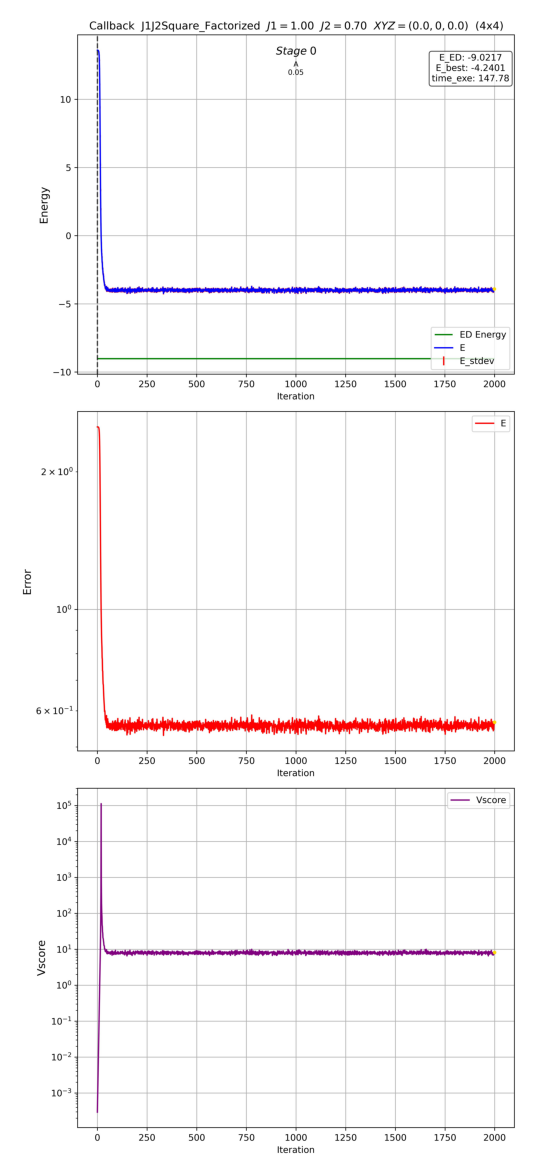



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.7_XYZ_0.0_0.0_0.0_date_20260130T115051_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 6.55000611,  6.50161424, -6.60624458,  6.51107919, -6.78003891,
       -6.32511854,  6.6029054 , -6.31681078,  6.86447217,  6.3387503 ,
       -6.75388432,  6.32431112, -6.74551386, -6.33056538,  6.54714618,
       -6.35523485], dtype=float64)}}
[[ 1  1 -1  1]
 [-1 -1  1 -1]
 [ 1  1 -1  1]
 [-1 -1  1 -1]]


Distance with Neel:     8.0 (Neel-B)
Distance with Stripped: 8.0 (Stripped-HA)




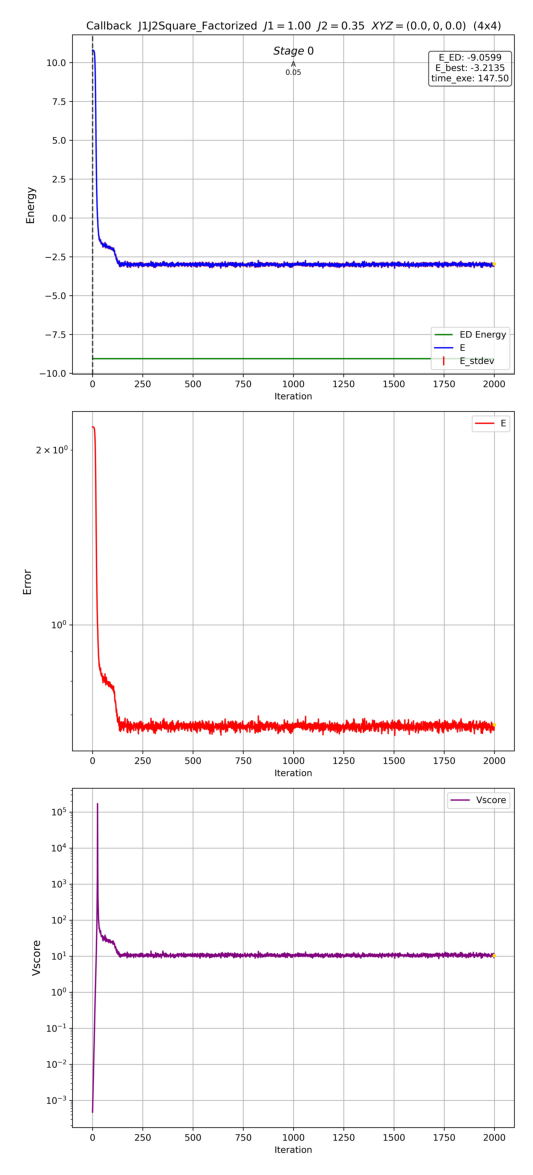



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.35_XYZ_0.0_0.0_0.0_date_20260130T113225_UUID_9366a696.json
{'Trans_0': {'phi': Array([ 6.82377289,  6.73768542, -6.15847341,  7.13596762, -6.99402187,
        5.78707814, -7.23973356,  5.63990063, -6.93539617,  6.71467255,
       -6.48215947,  7.02186648,  5.58590475, -6.90029302,  6.37825199,
       -6.96046801], dtype=float64)}}
[[ 1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]]


Distance with Neel:     10.0 (Neel-B)
Distance with Stripped: 10.0 (Stripped-VB)




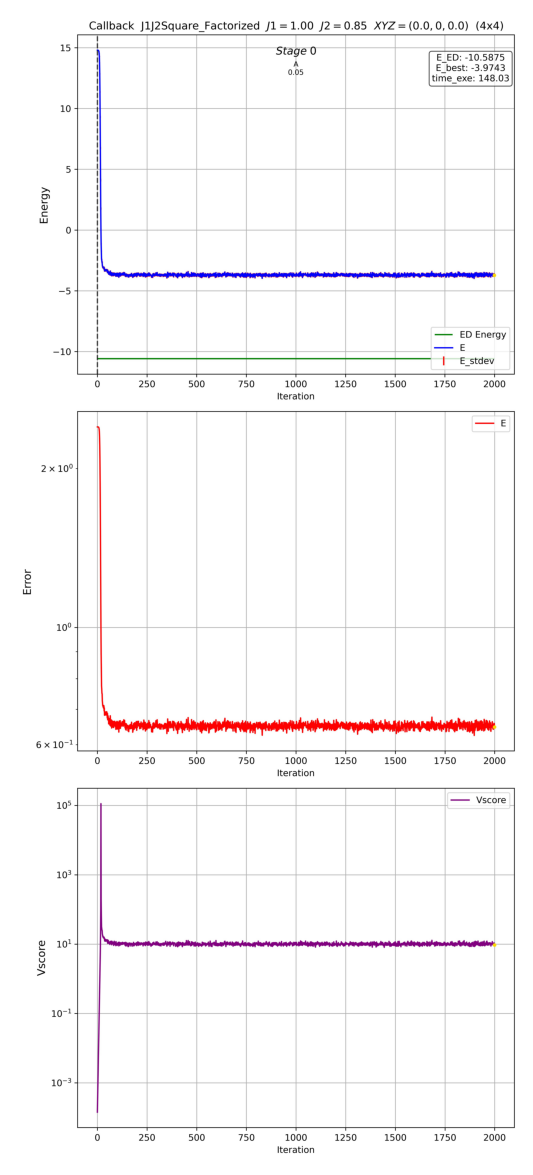



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.85_XYZ_0.0_0.0_0.0_date_20260130T115846_UUID_9366a696.json
{'Trans_0': {'phi': Array([-5.86759727,  6.93611584,  6.44126503,  6.92557662,  6.40014786,
       -6.89899344, -6.37566989, -7.06205648,  6.57914885, -6.24051585,
        6.80153263,  5.9685197 ,  6.73946639, -6.70613066, -6.46356968,
       -6.95284077], dtype=float64)}}
[[-1  1  1  1]
 [ 1 -1 -1 -1]
 [ 1 -1  1  1]
 [ 1 -1 -1 -1]]


Distance with Neel:     12.0 (Neel-B)
Distance with Stripped: 8.0 (Stripped-HA)




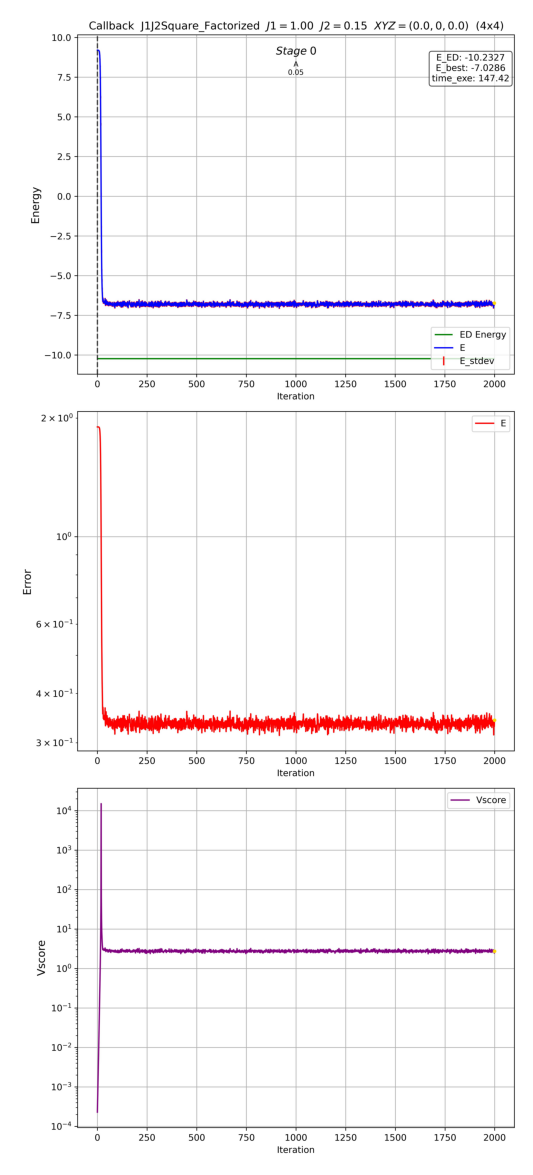



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_0.15_XYZ_0.0_0.0_0.0_date_20260130T112153_UUID_9366a696.json
{'Trans_0': {'phi': Array([-6.42455115,  6.43698614, -6.42553491,  6.43610122,  6.42222246,
       -6.44061824,  6.42790639, -6.43645465, -6.4247515 ,  6.43424828,
       -6.42945036,  6.43899744,  6.42489576, -6.43573568,  6.42725917,
       -6.44460734], dtype=float64)}}
[[-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]]


Distance with Neel:     0.0 (Neel-B)
Distance with Stripped: 16.0 (Stripped-VA-VB-HA-HB)




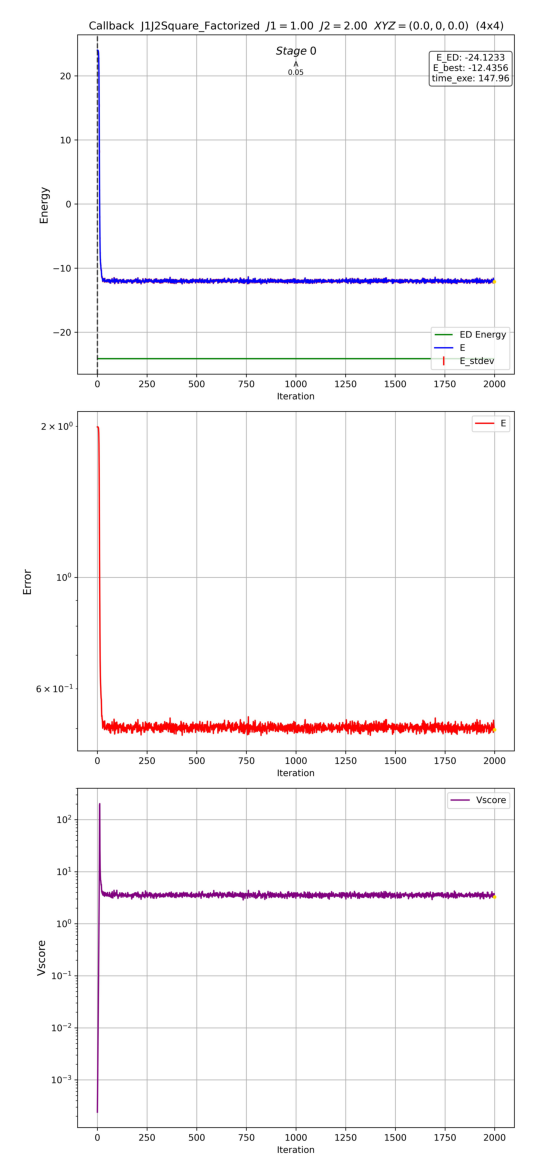



File: /home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/J1J2Square/Factorized_Transversal_Factorized/Size_4x4/ST_2000-A/UUID_9366a696/J1J2Square_Factorized_results_4x4_J1J2_1.0_2.0_XYZ_0.0_0.0_0.0_date_20260130T120921_UUID_9366a696.json
{'Trans_0': {'phi': Array([-7.00457786,  6.57830426, -6.90172867,  6.59876224,  6.67947293,
        6.85715212, -7.12989186,  6.81077382, -6.99424363,  6.58261861,
       -6.94360435,  6.5894598 , -7.09620466,  6.94894114, -7.10807281,
        6.90944715], dtype=float64)}}
[[-1  1 -1  1]
 [ 1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]]


Distance with Neel:     14.0 (Neel-B)
Distance with Stripped: 2.0 (Stripped-VB)




In [3]:
import glob
from NN_module.saveNload import load_pytree
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import jax.numpy as jnp

neel = distance_with_neel((4,4))
stripped = distance_with_stripped((4,4))

parent = "/home/ihuarte/Escritorio/Ivan/NNs/test_in_J2_Factorized/"
paths_list = glob.glob(parent + "**/*_results_*.json", recursive=True)

for path in paths_list:

    with open(path, 'r') as f:
        artifact = json.load(f)

    param_path =artifact["_artifacts"]["parameters"]
    callback_path = artifact["_artifacts"]["callback"]["plot"]

    img = mpimg.imread(callback_path)
    plt.figure(figsize=(15,15))
    plt.imshow(img)
    plt.axis('off')  
    plt.show()

    parameters = load_pytree(param_path)
    print("\n")
    print(f"File: {path}")
    print(parameters)
    parameters = parameters['Trans_0']['phi'].reshape((4,4))
    filtered_params = jnp.where(parameters < 0, -1, 1)
    print(filtered_params) 

    dist_neel, neel_label = neel(filtered_params)
    dist_strip, strip_label = stripped(filtered_params)

    print("\n")
    print(f"Distance with Neel:     {dist_neel} ({neel_label})")
    print(f"Distance with Stripped: {dist_strip} ({strip_label})")

    print("\n")

In [1]:
%run ./VMC_simulation.py

[CudaDevice(id=0)]
Configurations:
 - /home/ihuarte/Escritorio/Ivan/NNs/config.json
 - /home/ihuarte/Escritorio/Ivan/NNs/config_CM.json
 - /home/ihuarte/Escritorio/Ivan/NNs/config_Hydra.json
 - /home/ihuarte/Escritorio/Ivan/NNs/config_Hydra_NN.json
Running exact diagonalization...


In [2]:
mod = jnp.abs(x_ED)
phase = jnp.angle(x_ED)

In [3]:
no_null_mod_mask = mod > 1e-12
phase_hist = phase[no_null_mod_mask]

In [7]:
counts, values = jnp.histogram(phase_hist, bins=1000000)
counts, values

(Array([6246.,    0.,    0., ...,    0.,    0., 6624.], dtype=float64),
 Array([-0.68933348, -0.68933034, -0.68932719, ...,  2.45225289,
         2.45225603,  2.45225918], dtype=float64))

In [14]:
nonzero_mask = jnp.where(counts != 0.0)[0]
nonzero_mask

Array([     0, 999999], dtype=int64)

In [15]:
nonzero_counts, nonzero_values = counts[nonzero_mask], values[nonzero_mask]

In [16]:
nonzero_counts, nonzero_values

(Array([6246., 6624.], dtype=float64),
 Array([-0.68933348,  2.45225603], dtype=float64))

In [ ]:
from NN_module.schedule.schedule import Schedule
import optax

setup = {
    "print_arch": True,
    "learning_rate": {
        "epochs_struct": [[[50], [100], [200]]],
        "modes_struct": [[[["A"]], [["1", "110"]], [["10000"]]]],
        "lr_struct": [
            [[[0.01, 0.05]], [["lin(0.001, 0.1)", 0.3]], [["exp(0.1, 0.001)"]]]
        ],
        "repeat": [],
        "rescale": 1.0,
    },
    "architecture": {},
    "sampler": {},
}


sch = Schedule(setup, vstate.parameters)
sch.total_epochs
opt = optax.sgd
for period, info in sch.schedule():
    print(f"{info}")
    print(f"{period} {type(period)}\n")
    sch.transform_optimizer(vstate.parameters, opt, info, period)
    print("\n")

In [ ]:
import flax.linen as nn

arch_name = type(model).__name__
subarch_names = [
    name
    for name in model.__dict__.keys()
    if isinstance(model.__dict__[name], nn.Module)
]
arch_name, subarch_names

In [ ]:
model.__dict__["Trans"][0].__class__.__name__

In [ ]:
def is_subsequence(a, b):
    n, m = len(a), len(b)
    for i in range(m - n + 1):
        if b[i : i + n] == a:
            return True
    return False


a = (1, 2, 3)
b = (1, 2, 4, 3, 4, 5, 6)
is_subsequence(a, b)

In [ ]:
factory.setup